# F3-A - Estratégia A: tradução direta de linguagem natural para Nile

Este notebook executa a estratégia de referência da Fase 3. A F3-A recebe uma intenção em linguagem natural escrita em inglês e solicita diretamente ao modelo aluno uma expressão completa em Nile, sem Representação Intermediária, sem justificativas auxiliares e sem autocorreção.

A estratégia utiliza o modelo aluno `Qwen2.5-1.5B-Instruct` com geração determinística. O desenho experimental é herdado integralmente do pacote congelado `f3_modelo_operacional.zip`, que fornece o CAMPI canônico, os cinco folds, as seleções few-shot, o template oficial, o validador, as métricas e o esquema comum dos resultados.

A grade da F3-A contém dez condições:

- uma condição zero-shot, com `k=0`;
- nove condições few-shot, formadas por `k=1`, `k=3` e `k=5` combinados com seleção aleatória, lexical e semântica.

Cada condição avalia os 50 exemplos, sempre no fold em que o exemplo pertence ao conjunto de teste. Portanto, a execução completa produz:

```text
10 condições × 50 exemplos = 500 saídas Nile
```

O fluxo metodológico é:

```text
f3_modelo_operacional.zip
        ↓
auditoria da base comum
        ↓
plano fechado de 500 execuções
        ↓
montagem e auditoria dos prompts
        ↓
Qwen2.5-1.5B-Instruct
        ↓
extração da saída Nile
        ↓
parser → AST → verificação estrutural
        ↓
PSR, EM, ED, NED, SLA-S e SLA-F
        ↓
f3a_traducao_direta.zip
```

A F3-A não corrige saídas inválidas. Essas saídas são preservadas exatamente como produzidas e serão consumidas pela F3-B, responsável pela primeira autocorreção. O notebook também não utiliza IR, R1, R2 ou R3 no prompt de teste.

A execução é incremental. Cada geração é gravada imediatamente em um checkpoint, permitindo retomar o notebook sem repetir respostas compatíveis. O reaproveitamento só ocorre quando o ID da execução, o hash do prompt, a fonte do modelo e os parâmetros de geração permanecem idênticos.

| Bloco | Etapa | Função metodológica | Resultado principal |
|---:|---|---|---|
| 1 | Configuração | Fixar ambiente, parâmetros, caminhos e funções comuns | Base reprodutível da F3-A |
| 2 | Auditoria do F3-modelo | Localizar e verificar os 30 arquivos da base comum | Entrada operacional íntegra |
| 3 | Base formal | Carregar CAMPI, folds, seleções, módulos e schema | 50 registros e núcleo de avaliação |
| 4 | Plano experimental | Materializar as dez condições e 500 execuções | `f3a_plano_execucao.csv` |
| 5 | Modelo aluno | Resolver a fonte e carregar o Qwen2.5-1.5B-Instruct | Tokenizer e modelo prontos |
| 6 | Prompts | Montar, tokenizar e auditar todos os prompts | `f3a_prompts.jsonl.gz` |
| 7 | Inferência | Executar ou retomar as 500 gerações | Checkpoint e respostas brutas |
| 8 | Avaliação | Extrair Nile e calcular as seis métricas | Resultados detalhados validados |
| 9 | Consolidação | Produzir tabelas, análises e gráficos | Resumos por condição, fold e exemplo |
| 10 | Empacotamento | Registrar proveniência, hashes e inventário | `f3a_traducao_direta.zip` |

## Bloco 1 - Configuração inicial

### Objetivo

Este bloco prepara o ambiente da F3-A e concentra todas as escolhas que devem permanecer fixas durante a execução. A centralização evita alterações silenciosas entre condições e facilita a comparação com as demais estratégias.

### Configurações principais

O bloco define:

- estratégia `F3-A` e variante `sem_ac`;
- conjunto CAMPI com 50 exemplos e cinco folds;
- semente global `42`;
- `k=0`, `k=1`, `k=3` e `k=5`;
- regime zero-shot e métodos Aleatória, Lexical e Semântica;
- modelo aluno `Qwen2.5-1.5B-Instruct`;
- geração determinística com `do_sample=False`;
- limite de 256 novos tokens para Nile;
- política de retomada por checkpoint;
- diretórios de entrada, trabalho, resultados, tabelas, gráficos e pacote final.

### Retomada e teste rápido

`REINICIAR_EXECUCAO=False` preserva checkpoints compatíveis. Quando definido como `True`, somente os artefatos da execução da F3-A são removidos; os datasets de entrada permanecem intactos.

`MODO_TESTE_RAPIDO=False` corresponde à execução oficial. O modo rápido existe apenas para verificar o fluxo com poucos registros e não permite gerar o pacote final aprovado.

### Funções comuns

Também são definidas funções para JSON, JSONL, GZIP, CSV, SHA-256, ZIP, serialização canônica, limpeza de caches e exibição padronizada de tabelas.

### Resultado esperado

Ao final, os diretórios estarão preparados e a configuração inicial será salva. Este bloco não carrega dados e não exibe tabelas.

In [1]:
# ----------------------------------------------------------
# 1.1 Importação das bibliotecas principais
# ----------------------------------------------------------

import gc
import gzip
import hashlib
import importlib.metadata
import json
import os
import platform
import shutil
import sys
import time
import traceback
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


# ----------------------------------------------------------
# 1.2 Identificação da estratégia
# ----------------------------------------------------------

FASE = "F3-A"
ESTRATEGIA = "F3-A"
VARIANTE = "sem_ac"
NOME_ESTRATEGIA = "Tradução direta de linguagem natural para Nile"
DATASET = "CAMPI"

TOTAL_EXEMPLOS_ESPERADO = 50
TOTAL_FOLDS_ESPERADO = 5
TOTAL_CONDICOES_ESPERADO = 10
TOTAL_REGISTROS_ESPERADO = 500
SEED_GLOBAL = 42

K_ZERO_SHOT = [0]
K_FEWSHOT = [1, 3, 5]
VALORES_K = [0, 1, 3, 5]

METODO_ZERO_SHOT = "zero_shot"
METODOS_FEWSHOT = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]

ORDEM_METODOS_EXIBICAO = [
    METODO_ZERO_SHOT,
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]

ORDEM_METODOS_MAPA = {
    metodo: posicao
    for posicao, metodo in enumerate(ORDEM_METODOS_EXIBICAO)
}

ROTULOS_METODOS = {
    "zero_shot": "Nenhum (zero-shot)",
    "random_seed42": "Aleatória",
    "lexical_tfidf": "Lexical",
    "semantic_embeddings": "Semântica",
}

CORES_METODOS = {
    "zero_shot": "#d62728",
    "random_seed42": "#f2c94c",
    "lexical_tfidf": "#2ca02c",
    "semantic_embeddings": "#1f77b4",
}

METRICAS = ["psr", "em", "ed", "ned", "sla_s", "sla_f"]
ROTULOS_METRICAS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}


# ----------------------------------------------------------
# 1.3 Modelo aluno e geração
# ----------------------------------------------------------

MODELO_ALUNO = "Qwen2.5-1.5B-Instruct"
MODELO_HF_ID = "Qwen/Qwen2.5-1.5B-Instruct"
MODELO_LOCAL_HINTS = ["qwen2.5", "1.5b", "instruct"]

USAR_CUDA = True
PERMITIR_DOWNLOAD_HUGGINGFACE = True
MAX_NEW_TOKENS_NILE = 256
DO_SAMPLE = False
LIMITE_CONTEXTO_FALLBACK = 32768


# ----------------------------------------------------------
# 1.4 Controle de execução
# ----------------------------------------------------------

REINICIAR_EXECUCAO = False
MODO_TESTE_RAPIDO = False
TOTAL_REGISTROS_TESTE_RAPIDO = 5
INTERVALO_SNAPSHOT = 25


# ----------------------------------------------------------
# 1.5 Diretórios principais
# ----------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")
RAIZ_TRABALHO = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/mnt/data/f3a_working")
)

F3A_DIR = RAIZ_TRABALHO / "f3a_traducao_direta"
ENTRADAS_DIR = F3A_DIR / "entradas"
INTERMEDIARIOS_DIR = F3A_DIR / "intermediarios"
RESULTADOS_DIR = F3A_DIR / "resultados"
TABELAS_DIR = F3A_DIR / "tabelas"
GRAFICOS_DIR = F3A_DIR / "graficos"
RELATORIOS_DIR = F3A_DIR / "relatorios"
PACOTE_DIR = F3A_DIR / "pacote"
F3_MODELO_DIR = ENTRADAS_DIR / "f3_modelo_operacional"

if REINICIAR_EXECUCAO and F3A_DIR.exists():
    shutil.rmtree(F3A_DIR)

for diretorio in [
    F3A_DIR,
    ENTRADAS_DIR,
    INTERMEDIARIOS_DIR,
    RESULTADOS_DIR,
    TABELAS_DIR,
    GRAFICOS_DIR,
    RELATORIOS_DIR,
    PACOTE_DIR,
]:
    diretorio.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# 1.6 Caminhos dos artefatos da F3-A
# ----------------------------------------------------------

CONFIG_PATH = PACOTE_DIR / "f3a_config.json"
PLANO_PATH = PACOTE_DIR / "f3a_plano_execucao.csv"
PROMPTS_PATH = PACOTE_DIR / "f3a_prompts.jsonl.gz"
TOKEN_AUDIT_PATH = PACOTE_DIR / "f3a_token_audit.csv"
CHECKPOINT_PATH = INTERMEDIARIOS_DIR / "f3a_checkpoint.jsonl"
GENERATIONS_PATH = PACOTE_DIR / "f3a_generations.jsonl.gz"
RESULTS_JSONL_PATH = PACOTE_DIR / "f3a_results.jsonl"
RESULTS_CSV_PATH = PACOTE_DIR / "f3a_results.csv"
SUMMARY_PATH = PACOTE_DIR / "f3a_summary.csv"
SUMMARY_FOLD_PATH = PACOTE_DIR / "f3a_summary_by_fold.csv"
INVALID_PATH = PACOTE_DIR / "f3a_invalid_outputs.csv"
ANALYSIS_EXAMPLE_PATH = PACOTE_DIR / "f3a_analysis_by_example.csv"
EXECUTION_AUDIT_PATH = PACOTE_DIR / "f3a_execution_audit.csv"
MANIFEST_PATH = PACOTE_DIR / "manifest.json"
ZIP_FINAL_PATH = RAIZ_TRABALHO / "f3a_traducao_direta.zip"


# ----------------------------------------------------------
# 1.7 Funções de leitura, escrita e hashing
# ----------------------------------------------------------

def canonical_json(data):
    return json.dumps(
        data,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, ensure_ascii=False, indent=2)
        handle.write("\n")


def read_jsonl(path):
    records = []
    path = Path(path)
    if not path.exists():
        return records
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSONL inválido em {path}, linha {line_number}: {exc}"
                ) from exc
            if not isinstance(record, dict):
                raise TypeError(
                    f"Registro não é objeto em {path}, linha {line_number}."
                )
            records.append(record)
    return records


def write_jsonl(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")


def append_jsonl(record, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
        handle.write("\n")
        handle.flush()
        os.fsync(handle.fileno())


def write_jsonl_gz(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")


def package_version(name):
    try:
        return importlib.metadata.version(name)
    except Exception:
        return None


def clean_runtime_caches(root):
    root = Path(root)
    for cache in root.rglob("__pycache__"):
        if cache.is_dir():
            shutil.rmtree(cache, ignore_errors=True)
    for suffix in ("*.pyc", "*.pyo"):
        for item in root.rglob(suffix):
            item.unlink(missing_ok=True)


# ----------------------------------------------------------
# 1.8 Padrão visual das tabelas
# ----------------------------------------------------------

CONTADOR_TABELAS = 0

ROTULOS_COLUNAS = {
    "execution_id": "ID da execução",
    "fold": "fold",
    "id": "ID",
    "test_id": "ID de teste",
    "strategy": "estratégia",
    "variant": "variante",
    "regime": "regime",
    "selection_method": "método de seleção",
    "selection_label": "rótulo do método",
    "k": "k",
    "records": "registros",
    "total": "total",
    "status": "status",
    "item": "item",
    "value": "valor",
    "file": "arquivo",
    "path": "caminho",
    "size_bytes": "tamanho em bytes",
    "sha256": "SHA-256",
    "prompt_tokens": "tokens do prompt",
    "generated_tokens": "tokens gerados",
    "elapsed_seconds": "tempo em segundos",
    "syntax_valid": "validade sintática",
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}


def _display_value(value):
    if isinstance(value, (bool, np.bool_)):
        return "sim" if value else "não"
    if value is None:
        return "-"
    try:
        if not isinstance(value, str) and pd.isna(value):
            return "-"
    except Exception:
        pass
    return value


def exibir_tabela(df, titulo=None, altura_px=None, mostrar_indice=False):
    global CONTADOR_TABELAS
    if df is None:
        print("Tabela não disponível.")
        return
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    if df.empty:
        print("Tabela vazia.")
        return

    CONTADOR_TABELAS += 1
    tabela = df.copy()
    for coluna in tabela.columns:
        tabela[coluna] = tabela[coluna].apply(_display_value)
    tabela = tabela.rename(
        columns={
            coluna: ROTULOS_COLUNAS.get(coluna, str(coluna).replace("_", " "))
            for coluna in tabela.columns
        }
    )

    titulo_final = f"Tabela {CONTADOR_TABELAS}"
    if titulo:
        titulo_final += f". {titulo}"

    html_tabela = tabela.to_html(
        escape=True,
        index=mostrar_indice,
        border=0,
        justify="left",
        classes="tabela_saida",
    )
    altura_css = (
        "overflow-y: visible;"
        if altura_px is None
        else f"max-height: {altura_px}px; overflow-y: auto;"
    )

    display(HTML(f"""
    <div style="font-weight:600;font-size:15px;margin:8px 0 6px;color:#f1f1f1;">
        {titulo_final}
    </div>
    <div class="container_tabela_saida" style="display:inline-block;max-width:100%;overflow-x:auto;{altura_css}border:none;margin:8px 0 12px;">
        <style>
            .container_tabela_saida table.tabela_saida {{
                border-collapse:collapse !important;
                table-layout:auto !important;
                width:auto !important;
                font-family:Arial,sans-serif !important;
                font-size:13px !important;
                background:#111 !important;
                color:#f1f1f1 !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida thead th {{
                position:sticky !important;
                top:0 !important;
                z-index:2 !important;
                background:#2b2b2b !important;
                color:#fff !important;
                padding:7px !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #777 !important;
                border-bottom:2px solid #888 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody td {{
                padding:7px !important;
                vertical-align:top !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(even) td {{background:#1b1b1b !important;}}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(odd) td {{background:#111 !important;}}
        </style>
        {html_tabela}
    </div>
    """))


# ----------------------------------------------------------
# 1.9 Registro da configuração inicial
# ----------------------------------------------------------

configuracao_inicial = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variant": VARIANTE,
    "dataset": DATASET,
    "expected_examples": TOTAL_EXEMPLOS_ESPERADO,
    "expected_folds": TOTAL_FOLDS_ESPERADO,
    "expected_conditions": TOTAL_CONDICOES_ESPERADO,
    "expected_records": TOTAL_REGISTROS_ESPERADO,
    "seed": SEED_GLOBAL,
    "k_values": VALORES_K,
    "selection_methods": [METODO_ZERO_SHOT, *METODOS_FEWSHOT],
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "resume": {
        "restart": REINICIAR_EXECUCAO,
        "checkpoint": str(CHECKPOINT_PATH),
    },
    "quick_test": {
        "enabled": MODO_TESTE_RAPIDO,
        "records": TOTAL_REGISTROS_TESTE_RAPIDO,
    },
}
write_json(configuracao_inicial, CONFIG_PATH)

print("Bloco 1 concluído.")
print(f"Estratégia: {ESTRATEGIA} - {NOME_ESTRATEGIA}")
print(f"Execução oficial: {'não' if MODO_TESTE_RAPIDO else 'sim'}")
print(f"Retomada de checkpoint: {'não' if REINICIAR_EXECUCAO else 'sim'}")
print(f"Diretório de trabalho: {F3A_DIR}")
print("Status: OK")

Bloco 1 concluído.
Estratégia: F3-A - Tradução direta de linguagem natural para Nile
Execução oficial: sim
Retomada de checkpoint: sim
Diretório de trabalho: /kaggle/working/f3a_traducao_direta
Status: OK


## Bloco 2 - Localização e auditoria do F3-modelo

### Objetivo

Este bloco localiza o pacote operacional que congelou a base comum da Fase 3 e verifica sua integridade antes de qualquer montagem de prompt.

### Formas aceitas

O F3-modelo pode estar disponível:

- como diretório já montado pelo Kaggle;
- como arquivo `f3_modelo_operacional.zip`;
- como variante do mesmo nome acrescida de sufixos de cópia.

Quando a entrada é um ZIP, o conteúdo é extraído para a área de trabalho. O pacote original não é modificado.

### Auditoria realizada

O bloco confere:

- `manifest.json` e identificação da fase `F3-modelo`;
- conjunto CAMPI e quantidade de 50 exemplos;
- 30 arquivos no pacote;
- tamanho e SHA-256 dos 29 arquivos inventariados no manifesto;
- presença dos módulos, dados, prompts e auditorias obrigatórias;
- grade com 74 condições e 3.700 registros globais;
- seleção few-shot restrita ao treino;
- ausência de vazamento por ID, Nile, IR ou equivalência formal;
- auditoria completa dos prompts da base comum.

### Barreira metodológica

A F3-A não reconstrói folds, seleções ou templates. Ela consome exatamente os artefatos congelados. Qualquer divergência de hash interrompe a execução.

### Resultado esperado

A tabela apresenta a origem localizada e o resumo da integridade. O caminho validado passa a ser a única entrada operacional dos blocos seguintes.

In [2]:
# ----------------------------------------------------------
# 2.1 Localização do pacote operacional da F3-modelo
# ----------------------------------------------------------

def _candidate_roots():
    roots = []
    for root in [KAGGLE_INPUT, Path("/mnt/data"), Path.cwd()]:
        if root.exists() and root not in roots:
            roots.append(root)
    return roots


def locate_f3_modelo():
    directory_candidates = []
    zip_candidates = []

    for root in _candidate_roots():
        for manifest_path in root.rglob("manifest.json"):
            parent = manifest_path.parent
            if F3A_DIR in parent.parents or parent == F3A_DIR:
                continue
            if (parent / "f3_common.py").is_file() and (parent / "f3_grid.csv").is_file():
                try:
                    manifest = read_json(manifest_path)
                except Exception:
                    continue
                if manifest.get("phase") == "F3-modelo":
                    directory_candidates.append(parent)

        for zip_path in root.rglob("*.zip"):
            normalized = zip_path.name.lower().replace("-", "_")
            if "f3_modelo_operacional" in normalized or "f3_modelo_operacional" in normalized.replace(" ", ""):
                zip_candidates.append(zip_path)

    directory_candidates = sorted(set(directory_candidates), key=lambda p: (len(p.parts), str(p)))
    zip_candidates = sorted(set(zip_candidates), key=lambda p: (len(p.parts), str(p)))

    if directory_candidates:
        return "diretorio", directory_candidates[0]
    if zip_candidates:
        return "zip", zip_candidates[0]

    raise FileNotFoundError(
        "Nenhum diretório ou ZIP válido do F3-modelo foi localizado. "
        "Adicione f3_modelo_operacional ao dataset do Kaggle."
    )


TIPO_FONTE_F3_MODELO, FONTE_F3_MODELO = locate_f3_modelo()

if TIPO_FONTE_F3_MODELO == "zip":
    if F3_MODELO_DIR.exists():
        shutil.rmtree(F3_MODELO_DIR)
    F3_MODELO_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(FONTE_F3_MODELO, "r") as package:
        package.extractall(F3_MODELO_DIR)
else:
    F3_MODELO_DIR = Path(FONTE_F3_MODELO)


# ----------------------------------------------------------
# 2.2 Conferência do manifesto e dos hashes
# ----------------------------------------------------------

F3_MODELO_MANIFEST_PATH = F3_MODELO_DIR / "manifest.json"
if not F3_MODELO_MANIFEST_PATH.is_file():
    raise FileNotFoundError(F3_MODELO_MANIFEST_PATH)

f3_modelo_manifest = read_json(F3_MODELO_MANIFEST_PATH)
f3_modelo_manifest_sha256 = sha256_file(F3_MODELO_MANIFEST_PATH)

if f3_modelo_manifest.get("phase") != "F3-modelo":
    raise ValueError("O manifesto localizado não pertence à F3-modelo.")
if f3_modelo_manifest.get("dataset") != DATASET:
    raise ValueError("O conjunto registrado no F3-modelo não é CAMPI.")

file_audit_rows = []
for item in f3_modelo_manifest.get("files", []):
    relative = item["file"]
    path = F3_MODELO_DIR / relative
    exists = path.is_file()
    size_ok = exists and int(path.stat().st_size) == int(item["size_bytes"])
    hash_actual = sha256_file(path) if exists else None
    hash_ok = exists and hash_actual == item["sha256"]
    file_audit_rows.append({
        "file": relative,
        "size_bytes": int(path.stat().st_size) if exists else None,
        "sha256": hash_actual,
        "status": "compatível" if exists and size_ok and hash_ok else "incompatível",
    })

file_audit_df = pd.DataFrame(file_audit_rows)
if file_audit_df.empty or not file_audit_df["status"].eq("compatível").all():
    problematic = file_audit_df.loc[file_audit_df["status"] != "compatível"]
    raise ValueError(
        "A auditoria do F3-modelo encontrou arquivos ausentes ou divergentes: "
        + ", ".join(problematic["file"].astype(str).tolist())
    )

required_files = [
    "f3_common.py",
    "f3_config.json",
    "f3_equivalencia_formal.csv",
    "f3_exemplos_fewshot.jsonl",
    "f3_grid.csv",
    "f3_prompt_audit.csv",
    "f3_result_schema.json",
    "f3_selecao_fewshot.csv",
    "inputs/campi_canonical.csv",
    "inputs/folds.csv",
    "inputs/nile_core.py",
    "inputs/nile_metrics.py",
    "inputs/nile_subset.lark",
    "inputs/ir_references.jsonl",
    "inputs/rationales_references.jsonl",
    "prompts/f3a_traducao_direta.txt",
]
missing_required = [name for name in required_files if not (F3_MODELO_DIR / name).is_file()]
if missing_required:
    raise FileNotFoundError("Arquivos obrigatórios ausentes: " + ", ".join(missing_required))


# ----------------------------------------------------------
# 2.3 Verificação dos compromissos metodológicos
# ----------------------------------------------------------

selection_manifest = f3_modelo_manifest.get("selection", {})
prompt_manifest = f3_modelo_manifest.get("prompt_audit", {})
grid_manifest = f3_modelo_manifest.get("experimental_grid", {})
method_manifest = f3_modelo_manifest.get("method", {})

checks = {
    "50 exemplos": f3_modelo_manifest.get("dataset") == "CAMPI",
    "74 condições globais": grid_manifest.get("configurations") == 74,
    "3.700 registros globais": grid_manifest.get("main_records") == 3700,
    "zero vazamento por ID": selection_manifest.get("id_leakage_records") == 0,
    "zero Nile idêntica": selection_manifest.get("same_nile_records") == 0,
    "zero IR idêntica": selection_manifest.get("same_ir_records") == 0,
    "zero equivalência formal": selection_manifest.get("formal_equivalence_records") == 0,
    "zero vazamento nos prompts": prompt_manifest.get("leakage_records") == 0,
    "auditoria cobre todos os testes": method_manifest.get("prompt_audit_covers_all_test_examples") is True,
}
failed_checks = [name for name, passed in checks.items() if not passed]
if failed_checks:
    raise ValueError("Compromissos metodológicos não confirmados: " + ", ".join(failed_checks))

source_summary_df = pd.DataFrame([
    {"item": "tipo de fonte", "value": TIPO_FONTE_F3_MODELO},
    {"item": "fonte localizada", "value": str(FONTE_F3_MODELO)},
    {"item": "diretório operacional", "value": str(F3_MODELO_DIR)},
    {"item": "arquivos inventariados", "value": len(file_audit_df)},
    {"item": "SHA-256 do manifesto", "value": f3_modelo_manifest_sha256},
    {"item": "vazamentos registrados", "value": 0},
])

exibir_tabela(source_summary_df, "Auditoria do pacote F3-modelo")
exibir_tabela(file_audit_df[["file", "size_bytes", "status"]], "Arquivos inventariados no F3-modelo", altura_px=420)

print("Bloco 2 concluído.")
print(f"Entrada operacional: {F3_MODELO_DIR}")
print("Integridade dos arquivos: confirmada")
print("Proteções contra vazamento: confirmadas")
print("Status: OK")

item,valor
tipo de fonte,diretorio
fonte localizada,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
diretório operacional,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
arquivos inventariados,29
SHA-256 do manifesto,bc798e1d152332a85747ffdc97390015e6b4e294e300e6a9a3b4664c1787f835
vazamentos registrados,0


arquivo,tamanho em bytes,status
f3_common.py,19714,compatível
f3_config.json,4319,compatível
f3_equivalencia_formal.csv,11601,compatível
f3_exemplos_fewshot.jsonl,170191,compatível
f3_grid.csv,5909,compatível
f3_input_audit.csv,844,compatível
f3_prompt_audit.csv,642966,compatível
f3_prompt_templates.json,4764,compatível
f3_result_schema.json,5649,compatível
f3_selecao_fewshot.csv,101374,compatível


Bloco 2 concluído.
Entrada operacional: /kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
Integridade dos arquivos: confirmada
Proteções contra vazamento: confirmadas
Status: OK


## Bloco 3 - Carga da base, dos módulos e das seleções

### Objetivo

Este bloco transforma os arquivos auditados em objetos de execução e confirma que os componentes formais continuam operacionais dentro da F3-A.

### Entradas carregadas

São carregados:

- CAMPI canônico;
- cinco folds;
- IRs de referência;
- R1, R2 e R3, apenas para auditoria de vazamento;
- mapa cumulativo das seleções few-shot;
- template oficial da F3-A;
- gramática do subconjunto Nile;
- núcleo `nile_core.py`;
- métricas `nile_metrics.py`;
- módulo comum `f3_common.py`;
- JSON Schema dos resultados.

### Verificações

O bloco confirma:

- 50 IDs únicos e correspondentes entre os artefatos;
- 40 exemplos de treino e 10 de teste por fold;
- cada exemplo em teste exatamente uma vez;
- 450 seleções cumulativas few-shot;
- nenhuma demonstração fora do treino;
- nenhuma equivalência formal com o teste;
- 50 referências Nile sintaticamente válidas;
- identidade perfeita das métricas ao comparar cada referência consigo mesma.

### Uso das justificativas

R1, R2 e R3 não são fornecidas ao modelo aluno na F3-A. Elas são carregadas somente para verificar que nenhuma justificativa pertencente ao exemplo de teste aparece acidentalmente em um prompt.

### Resultado esperado

A base integrada terá 50 registros com linguagem natural, Nile, IR e justificativas de auditoria. O validador e as métricas estarão prontos para uso.

In [3]:
# ----------------------------------------------------------
# 3.1 Importação controlada dos módulos da base comum
# ----------------------------------------------------------

sys.path.insert(0, str(F3_MODELO_DIR))

import importlib.util


def import_module_from_path(module_name, path):
    path = Path(path)
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Não foi possível importar {module_name} de {path}.")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


f3_common = import_module_from_path("f3_common_runtime", F3_MODELO_DIR / "f3_common.py")
nile_core = import_module_from_path("nile_core_runtime", F3_MODELO_DIR / "inputs/nile_core.py")
nile_metrics = import_module_from_path("nile_metrics_runtime", F3_MODELO_DIR / "inputs/nile_metrics.py")


# ----------------------------------------------------------
# 3.2 Carga dos artefatos tabulares e estruturados
# ----------------------------------------------------------

f3_config = read_json(F3_MODELO_DIR / "f3_config.json")
result_schema = read_json(F3_MODELO_DIR / "f3_result_schema.json")

campi_df = pd.read_csv(F3_MODELO_DIR / "inputs/campi_canonical.csv")
folds_df = pd.read_csv(F3_MODELO_DIR / "inputs/folds.csv")
grid_df = pd.read_csv(F3_MODELO_DIR / "f3_grid.csv")
selection_detail_df = pd.read_csv(F3_MODELO_DIR / "f3_selecao_fewshot.csv")
formal_equivalence_df = pd.read_csv(F3_MODELO_DIR / "f3_equivalencia_formal.csv")
prompt_audit_base_df = pd.read_csv(F3_MODELO_DIR / "f3_prompt_audit.csv")

ir_records = f3_common.read_jsonl(F3_MODELO_DIR / "inputs/ir_references.jsonl")
rationale_records = f3_common.read_jsonl(F3_MODELO_DIR / "inputs/rationales_references.jsonl")
selection_map = f3_common.load_selection_map(F3_MODELO_DIR / "f3_exemplos_fewshot.jsonl")

template_f3a = (F3_MODELO_DIR / "prompts/f3a_traducao_direta.txt").read_text(encoding="utf-8")
grammar_text = (F3_MODELO_DIR / "inputs/nile_subset.lark").read_text(encoding="utf-8")
validator = nile_core.NileValidator(grammar_text)


# ----------------------------------------------------------
# 3.3 Integração por ID
# ----------------------------------------------------------

ir_by_id = {record["id"]: record["ir"] for record in ir_records}
rationale_by_id = {record["id"]: record for record in rationale_records}

records_by_id = {}
for row in campi_df.to_dict(orient="records"):
    item_id = str(row["id"])
    if item_id not in ir_by_id or item_id not in rationale_by_id:
        raise KeyError(f"Artefatos auxiliares ausentes para {item_id}.")
    records_by_id[item_id] = {
        "id": item_id,
        "nl": str(row["nl"]),
        "nile": str(row["nile_canonical"]),
        "ir": ir_by_id[item_id],
        "r1": rationale_by_id[item_id]["r1"],
        "r2": rationale_by_id[item_id]["r2"],
        "r3": rationale_by_id[item_id]["r3"],
    }

expected_ids = [f"campi_{index:03d}" for index in range(1, TOTAL_EXEMPLOS_ESPERADO + 1)]
if sorted(records_by_id) != expected_ids:
    raise ValueError("Os IDs integrados não correspondem aos 50 exemplos esperados.")


# ----------------------------------------------------------
# 3.4 Auditoria dos folds e das seleções
# ----------------------------------------------------------

fold_counts = (
    folds_df
    .groupby(["fold", "split"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
if len(fold_counts) != TOTAL_FOLDS_ESPERADO:
    raise ValueError("Quantidade de folds divergente.")
if not fold_counts["train"].eq(40).all() or not fold_counts["test"].eq(10).all():
    raise ValueError("Cada fold deve conter 40 registros de treino e 10 de teste.")

test_occurrences = folds_df.loc[folds_df["split"] == "test", "id"].value_counts()
if set(test_occurrences.index) != set(expected_ids) or not test_occurrences.eq(1).all():
    raise ValueError("Cada exemplo deve aparecer em teste exatamente uma vez.")

if len(selection_map) != 450:
    raise ValueError(f"Esperadas 450 seleções cumulativas; encontradas {len(selection_map)}.")

selection_boolean_columns = [
    "pertence ao treino",
    "vazamento do teste",
    "Nile idêntica à do teste",
    "IR idêntica à do teste",
    "equivalência formal com o teste",
    "elegível",
]
for column in selection_boolean_columns:
    if column not in selection_detail_df.columns:
        raise KeyError(f"Coluna de auditoria ausente: {column}")

if not selection_detail_df["pertence ao treino"].astype(bool).all():
    raise ValueError("Há demonstração fora do conjunto de treino.")
if selection_detail_df["vazamento do teste"].astype(bool).any():
    raise ValueError("Há demonstração com o mesmo ID do teste.")
if selection_detail_df["Nile idêntica à do teste"].astype(bool).any():
    raise ValueError("Há demonstração com Nile idêntica à referência do teste.")
if selection_detail_df["IR idêntica à do teste"].astype(bool).any():
    raise ValueError("Há demonstração com IR idêntica à referência do teste.")
if selection_detail_df["equivalência formal com o teste"].astype(bool).any():
    raise ValueError("Há demonstração formalmente equivalente ao teste.")
if not selection_detail_df["elegível"].astype(bool).all():
    raise ValueError("Há demonstração marcada como não elegível.")


# ----------------------------------------------------------
# 3.5 Teste do núcleo formal e das métricas
# ----------------------------------------------------------

formal_rows = []
for item_id, record in records_by_id.items():
    validation = validator.validate(record["nile"])
    self_metrics = nile_metrics.evaluate_pair(record["nile"], record["nile"], validator)
    formal_rows.append({
        "id": item_id,
        "syntax_valid": bool(validation.get("syntax_valid", False)),
        "psr": self_metrics["psr"],
        "em": self_metrics["em"],
        "ed": self_metrics["ed"],
        "ned": self_metrics["ned"],
        "sla_s": self_metrics["sla_s"],
        "sla_f": self_metrics["sla_f"],
    })

formal_validation_df = pd.DataFrame(formal_rows)
if not formal_validation_df["syntax_valid"].all():
    raise ValueError("Há referência canônica sintaticamente inválida.")
if not formal_validation_df["psr"].eq(1).all():
    raise ValueError("Autocomparação com PSR diferente de 1.")
if not formal_validation_df["em"].eq(1).all():
    raise ValueError("Autocomparação com EM diferente de 1.")
if not formal_validation_df["ed"].eq(0).all():
    raise ValueError("Autocomparação com ED diferente de 0.")
if not formal_validation_df["ned"].eq(0).all():
    raise ValueError("Autocomparação com NED diferente de 0.")
if not formal_validation_df["sla_s"].eq(1).all():
    raise ValueError("Autocomparação com SLA-S diferente de 1.")
if not formal_validation_df["sla_f"].eq(1).all():
    raise ValueError("Autocomparação com SLA-F diferente de 1.")

resource_summary_df = pd.DataFrame([
    {"item": "exemplos integrados", "value": len(records_by_id)},
    {"item": "folds", "value": folds_df["fold"].nunique()},
    {"item": "seleções cumulativas", "value": len(selection_map)},
    {"item": "posições few-shot auditadas", "value": len(selection_detail_df)},
    {"item": "referências sintaticamente válidas", "value": int(formal_validation_df["syntax_valid"].sum())},
])

exibir_tabela(resource_summary_df, "Recursos carregados para a F3-A")
exibir_tabela(fold_counts, "Distribuição de treino e teste por fold")

print("Bloco 3 concluído.")
print("Base integrada: 50 exemplos")
print("Validador e métricas: aprovados")
print("Seleções few-shot: sem vazamento")
print("Status: OK")

item,valor
exemplos integrados,50
folds,5
seleções cumulativas,450
posições few-shot auditadas,750
referências sintaticamente válidas,50


fold,test,train
1,10,40
2,10,40
3,10,40
4,10,40
5,10,40


Bloco 3 concluído.
Base integrada: 50 exemplos
Validador e métricas: aprovados
Seleções few-shot: sem vazamento
Status: OK


## Bloco 4 - Construção do plano experimental da F3-A

### Objetivo

Este bloco materializa todas as execuções que devem ser realizadas, antes do carregamento do modelo aluno. O plano fechado impede que condições sejam criadas ou omitidas durante a inferência.

### Dez condições

O plano utiliza a seção F3-A de `f3_grid.csv`:

- `k=0` com `zero_shot`;
- `k=1`, `k=3` e `k=5` com `random_seed42`;
- `k=1`, `k=3` e `k=5` com `lexical_tfidf`;
- `k=1`, `k=3` e `k=5` com `semantic_embeddings`.

Cada condição contém os 50 exemplos no fold em que são teste. As demonstrações são recuperadas do mapa cumulativo congelado pelo F3-modelo.

### Informações registradas

Cada linha contém:

- ID único de execução;
- fold e ID de teste;
- regime, método e valor de `k`;
- IDs e escores das demonstrações;
- tamanho do universo elegível;
- grupo formal do teste;
- hash preliminar dos metadados da condição.

### Verificações

O bloco exige:

- dez condições únicas;
- 50 registros por condição;
- 500 execuções no total;
- nenhuma repetição de chave experimental;
- zero demonstrações no zero-shot;
- exatamente `k` demonstrações no few-shot;
- seleção cumulativa para `k=1`, `k=3` e `k=5`.

### Resultado esperado

O plano é salvo em `f3a_plano_execucao.csv` e será usado sem alterações nos blocos de prompt, inferência e avaliação.

In [4]:
# ----------------------------------------------------------
# 4.1 Seleção das condições oficiais da F3-A
# ----------------------------------------------------------

f3a_grid_df = grid_df.loc[grid_df["estratégia"] == ESTRATEGIA].copy()
f3a_grid_df["_ordem_metodo"] = (
    f3a_grid_df["método de seleção"]
    .map(ORDEM_METODOS_MAPA)
)
if f3a_grid_df["_ordem_metodo"].isna().any():
    metodos_desconhecidos = sorted(
        f3a_grid_df.loc[
            f3a_grid_df["_ordem_metodo"].isna(),
            "método de seleção",
        ].astype(str).unique().tolist()
    )
    raise ValueError(
        "Métodos sem ordem de exibição definida: "
        + ", ".join(metodos_desconhecidos)
    )
f3a_grid_df = (
    f3a_grid_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

if len(f3a_grid_df) != TOTAL_CONDICOES_ESPERADO:
    raise ValueError(
        f"Esperadas {TOTAL_CONDICOES_ESPERADO} condições da F3-A; "
        f"encontradas {len(f3a_grid_df)}."
    )

if set(f3a_grid_df["k"].astype(int)) != set(VALORES_K):
    raise ValueError("Valores de k divergentes na grade da F3-A.")


# ----------------------------------------------------------
# 4.2 Materialização das 500 execuções
# ----------------------------------------------------------

test_rows = folds_df.loc[folds_df["split"] == "test", ["fold", "id"]].copy()
test_rows = test_rows.sort_values(["fold", "id"]).reset_index(drop=True)

plan_rows = []
for condition in f3a_grid_df.to_dict(orient="records"):
    method = str(condition["método de seleção"])
    label = str(condition["rótulo do método"])
    k = int(condition["k"])
    regime = str(condition["regime"])

    for test_row in test_rows.to_dict(orient="records"):
        fold = int(test_row["fold"])
        test_id = str(test_row["id"])

        if k == 0:
            selected_ids = []
            scores = []
            derived_seed = None
            eligible_pool_size = 40
            formal_group = formal_equivalence_df.loc[
                formal_equivalence_df["id"] == test_id,
                "grupo formal",
            ].iloc[0]
        else:
            selection = selection_map[(fold, test_id, method, k)]
            selected_ids = list(selection["selected_ids"])
            scores = list(selection["scores"])
            derived_seed = selection.get("derived_seed")
            eligible_pool_size = int(selection.get("eligible_pool_size", 40))
            formal_group = selection.get("test_formal_group")

        execution_id = f"f3a|fold={fold}|id={test_id}|method={method}|k={k}"
        condition_payload = {
            "fold": fold,
            "test_id": test_id,
            "method": method,
            "k": k,
            "demonstration_ids": selected_ids,
        }

        plan_rows.append({
            "execution_id": execution_id,
            "strategy": ESTRATEGIA,
            "variant": VARIANTE,
            "fold": fold,
            "id": test_id,
            "regime": regime,
            "selection_method": method,
            "selection_label": label,
            "k": k,
            "demonstration_ids": selected_ids,
            "demonstration_scores": scores,
            "derived_seed": derived_seed,
            "eligible_pool_size": eligible_pool_size,
            "test_formal_group": formal_group,
            "condition_sha256": sha256_text(canonical_json(condition_payload)),
        })

plan_records = plan_rows
plan_df = pd.DataFrame(plan_rows)


# ----------------------------------------------------------
# 4.3 Verificações da grade materializada
# ----------------------------------------------------------

if len(plan_df) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError(
        f"Esperados {TOTAL_REGISTROS_ESPERADO} registros; encontrados {len(plan_df)}."
    )
if plan_df["execution_id"].duplicated().any():
    raise ValueError("O plano contém IDs de execução duplicados.")

condition_counts = (
    plan_df.groupby(
        ["regime", "selection_method", "selection_label", "k"],
        dropna=False,
    )
    .size()
    .reset_index(name="records")
)
condition_counts["_ordem_metodo"] = (
    condition_counts["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
condition_counts = (
    condition_counts
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
if len(condition_counts) != TOTAL_CONDICOES_ESPERADO or not condition_counts["records"].eq(50).all():
    raise ValueError("As condições não possuem exatamente 50 registros cada.")

for row in plan_records:
    if int(row["k"]) == 0 and row["demonstration_ids"]:
        raise ValueError("Uma condição zero-shot contém demonstrações.")
    if int(row["k"]) > 0 and len(row["demonstration_ids"]) != int(row["k"]):
        raise ValueError(f"Quantidade de demonstrações divergente em {row['execution_id']}.")
    if row["id"] in row["demonstration_ids"]:
        raise ValueError(f"Vazamento de ID em {row['execution_id']}.")

# Cumulatividade das listas de demonstrações.
for fold in range(1, TOTAL_FOLDS_ESPERADO + 1):
    for test_id in test_rows.loc[test_rows["fold"] == fold, "id"]:
        for method in METODOS_FEWSHOT:
            ids_1 = selection_map[(fold, test_id, method, 1)]["selected_ids"]
            ids_3 = selection_map[(fold, test_id, method, 3)]["selected_ids"]
            ids_5 = selection_map[(fold, test_id, method, 5)]["selected_ids"]
            if ids_3[:1] != ids_1 or ids_5[:3] != ids_3:
                raise ValueError(
                    f"Seleção não cumulativa para fold={fold}, id={test_id}, método={method}."
                )

plan_export_df = plan_df.copy()
for column in ["demonstration_ids", "demonstration_scores"]:
    plan_export_df[column] = plan_export_df[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False, separators=(",", ":"))
    )
plan_export_df.to_csv(PLANO_PATH, index=False, encoding="utf-8")

exibir_tabela(condition_counts, "Condições experimentais da F3-A")
exibir_tabela(
    plan_export_df[[
        "execution_id",
        "fold",
        "id",
        "selection_label",
        "k",
        "demonstration_ids",
    ]].head(20),
    "Amostra do plano de execução",
    altura_px=420,
)

print("Bloco 4 concluído.")
print(f"Condições: {len(condition_counts)}")
print(f"Execuções planejadas: {len(plan_df)}")
print("Valores few-shot: k=1, k=3 e k=5")
print("Plano fechado e cumulativo: confirmado")
print("Status: OK")

regime,método de seleção,rótulo do método,k,registros
zero-shot,zero_shot,Nenhum (zero-shot),0,50
few-shot,random_seed42,Aleatória,1,50
few-shot,lexical_tfidf,Lexical,1,50
few-shot,semantic_embeddings,Semântica,1,50
few-shot,random_seed42,Aleatória,3,50
few-shot,lexical_tfidf,Lexical,3,50
few-shot,semantic_embeddings,Semântica,3,50
few-shot,random_seed42,Aleatória,5,50
few-shot,lexical_tfidf,Lexical,5,50
few-shot,semantic_embeddings,Semântica,5,50


ID da execução,fold,ID,rótulo do método,k,demonstration ids
f3a|fold=1|id=campi_001|method=zero_shot|k=0,1,campi_001,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_002|method=zero_shot|k=0,1,campi_002,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_011|method=zero_shot|k=0,1,campi_011,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_012|method=zero_shot|k=0,1,campi_012,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_020|method=zero_shot|k=0,1,campi_020,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_023|method=zero_shot|k=0,1,campi_023,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_024|method=zero_shot|k=0,1,campi_024,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_027|method=zero_shot|k=0,1,campi_027,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_039|method=zero_shot|k=0,1,campi_039,Nenhum (zero-shot),0,[]
f3a|fold=1|id=campi_044|method=zero_shot|k=0,1,campi_044,Nenhum (zero-shot),0,[]


Bloco 4 concluído.
Condições: 10
Execuções planejadas: 500
Valores few-shot: k=1, k=3 e k=5
Plano fechado e cumulativo: confirmado
Status: OK


## Bloco 5 - Resolução e carregamento do modelo aluno

### Objetivo

Este bloco localiza e carrega o `Qwen2.5-1.5B-Instruct`, mantendo a fonte efetivamente utilizada registrada para o manifesto final.

### Resolução da fonte

A busca prioriza um diretório local montado no Kaggle que contenha o modelo. Para ser aceito, o caminho deve possuir `config.json` e corresponder aos identificadores `qwen2.5`, `1.5b` e `instruct`.

Quando nenhum modelo local é localizado e `PERMITIR_DOWNLOAD_HUGGINGFACE=True`, o identificador `Qwen/Qwen2.5-1.5B-Instruct` é utilizado. Caso a internet esteja desativada e não exista cópia local, o bloco encerra com uma mensagem explícita.

### Carregamento

O módulo comum do F3-modelo realiza:

- carregamento do tokenizer;
- carregamento do modelo causal;
- `float16` quando CUDA está disponível;
- `float32` em CPU;
- `device_map="auto"` em GPU;
- modo de avaliação;
- definição do token de padding quando necessário.

Não há quantização, fine-tuning ou amostragem.

### Limite de contexto

O limite é obtido da configuração efetivamente carregada. Valores sentinela do tokenizer são ignorados. Quando nenhuma informação válida é encontrada, utiliza-se apenas como barreira operacional o valor de fallback configurado.

### Resultado esperado

A tabela registra fonte, dispositivo, precisão, limite de contexto e memória da GPU. Nenhuma saída experimental é gerada neste bloco.

In [5]:
# ----------------------------------------------------------
# 5.1 Resolução da fonte do modelo aluno
# ----------------------------------------------------------

local_model_dir = f3_common.resolve_local_model_dir(
    KAGGLE_INPUT,
    MODELO_LOCAL_HINTS,
) if KAGGLE_INPUT.exists() else None

if local_model_dir is not None:
    MODEL_SOURCE = local_model_dir
    MODEL_SOURCE_TYPE = "diretório local do Kaggle"
    LOCAL_FILES_ONLY = True
elif PERMITIR_DOWNLOAD_HUGGINGFACE:
    MODEL_SOURCE = MODELO_HF_ID
    MODEL_SOURCE_TYPE = "Hugging Face"
    LOCAL_FILES_ONLY = False
else:
    raise FileNotFoundError(
        "O modelo aluno não foi localizado em /kaggle/input e o download está desativado."
    )


# ----------------------------------------------------------
# 5.2 Carregamento do tokenizer e do modelo
# ----------------------------------------------------------

try:
    import torch
    tokenizer, model = f3_common.load_student_model(
        MODEL_SOURCE,
        use_cuda=USAR_CUDA,
        local_files_only=LOCAL_FILES_ONLY,
    )
except Exception as exc:
    raise RuntimeError(
        "Não foi possível carregar o Qwen2.5-1.5B-Instruct. "
        "Confirme que o modelo está disponível no Kaggle ou habilite a internet. "
        f"Erro original: {exc}"
    ) from exc

model_device = str(next(model.parameters()).device)
model_dtype = str(next(model.parameters()).dtype)

context_candidates = []
for value in [
    getattr(getattr(model, "config", None), "max_position_embeddings", None),
    getattr(getattr(model, "config", None), "max_seq_len", None),
    getattr(tokenizer, "model_max_length", None),
]:
    try:
        numeric = int(value)
    except Exception:
        continue
    if 1024 <= numeric <= 1_000_000:
        context_candidates.append(numeric)

CONTEXT_LIMIT = min(context_candidates) if context_candidates else LIMITE_CONTEXTO_FALLBACK

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
else:
    gpu_name = None
    gpu_memory_gb = None

model_summary_df = pd.DataFrame([
    {"item": "modelo", "value": MODELO_ALUNO},
    {"item": "fonte utilizada", "value": str(MODEL_SOURCE)},
    {"item": "tipo da fonte", "value": MODEL_SOURCE_TYPE},
    {"item": "dispositivo", "value": model_device},
    {"item": "precisão", "value": model_dtype},
    {"item": "limite de contexto", "value": CONTEXT_LIMIT},
    {"item": "GPU", "value": gpu_name},
    {"item": "memória da GPU em GB", "value": round(gpu_memory_gb, 2) if gpu_memory_gb else None},
])

exibir_tabela(model_summary_df, "Modelo aluno carregado")

print("Bloco 5 concluído.")
print(f"Fonte do modelo: {MODEL_SOURCE}")
print(f"Dispositivo: {model_device}")
print(f"Limite de contexto adotado: {CONTEXT_LIMIT}")
print("Geração experimental iniciará no Bloco 7.")
print("Status: OK")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

item,valor
modelo,Qwen2.5-1.5B-Instruct
fonte utilizada,Qwen/Qwen2.5-1.5B-Instruct
tipo da fonte,Hugging Face
dispositivo,cuda:0
precisão,torch.float16
limite de contexto,32768
GPU,Tesla T4
memória da GPU em GB,14.56


Bloco 5 concluído.
Fonte do modelo: Qwen/Qwen2.5-1.5B-Instruct
Dispositivo: cuda:0
Limite de contexto adotado: 32768
Geração experimental iniciará no Bloco 7.
Status: OK


## Bloco 6 - Montagem, tokenização e auditoria dos prompts

### Objetivo

Este bloco constrói antecipadamente os 500 prompts da F3-A. Nenhum prompt é montado durante a inferência, o que permite auditar o conteúdo, calcular hashes e confirmar o limite de contexto antes de consumir tempo de GPU.

### Zero-shot e few-shot

No zero-shot, o placeholder de exemplos recebe a indicação de ausência de demonstrações. Nas condições few-shot, os exemplos são formatados como pares:

```text
Entrada em linguagem natural
Saída Nile
```

A ordem das demonstrações segue exatamente a seleção cumulativa do F3-modelo.

### Auditoria de vazamento

Para cada prompt, o bloco verifica:

- ausência de placeholders pendentes;
- ID de teste fora das demonstrações;
- Nile de referência do teste ausente;
- IR de referência do teste ausente;
- R1, R2 e R3 do teste ausentes;
- quantidade de demonstrações igual a `k`;
- hash único do prompt associado à execução.

A entrada em linguagem natural do teste aparece porque é o dado que deve ser traduzido. A saída de referência nunca é fornecida ao modelo aluno.

### Auditoria de tokens

Os prompts são convertidos pelo chat template do tokenizer. O bloco registra número de tokens, tokens máximos de saída e total reservado. A execução é interrompida quando:

```text
tokens do prompt + 256 > limite de contexto
```

### Artefatos produzidos

São salvos:

- `f3a_prompts.jsonl.gz`;
- `f3a_token_audit.csv`.

### Resultado esperado

O resumo apresenta 500 prompts, dez condições, zero vazamentos e os valores mínimo e máximo de tokens.

### Conferência cruzada da tokenização

A contagem utiliza o mesmo chat template e o mesmo campo `input_ids` empregados durante a inferência. No Bloco 7, a quantidade auditada antes da geração é comparada com a quantidade observada pelo modelo. Qualquer divergência interrompe a consolidação.

In [6]:
# ----------------------------------------------------------
# 6.1 Função de contagem pelo chat template
# ----------------------------------------------------------

def count_chat_tokens(prompt):
    messages = [{"role": "user", "content": prompt}]
    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    if "input_ids" not in encoded:
        raise ValueError(
            "O tokenizer não retornou input_ids na auditoria do prompt."
        )

    return int(encoded["input_ids"].shape[-1])


# ----------------------------------------------------------
# 6.2 Montagem dos prompts
# ----------------------------------------------------------

prompt_records = []
token_rows = []

for plan in plan_records:
    item_id = plan["id"]
    record = records_by_id[item_id]
    selected_ids = list(plan["demonstration_ids"])

    demos = f3_common.build_demos(selected_ids, records_by_id, "A")
    prompt = f3_common.build_prompt_a(template_f3a, record["nl"], demos)
    prompt_hash = sha256_text(prompt)
    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE

    pending_placeholders = "{{" in prompt or "}}" in prompt
    test_nile_exposed = record["nile"] in prompt
    test_ir_text = f3_common.canonical_json(record["ir"])
    test_ir_exposed = test_ir_text in prompt
    test_r1_exposed = record["r1"] in prompt
    test_r2_exposed = record["r2"] in prompt
    test_r3_exposed = record["r3"] in prompt
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    if pending_placeholders:
        raise ValueError(f"Placeholder pendente em {plan['execution_id']}.")
    if test_nile_exposed:
        raise ValueError(f"Nile de referência exposta em {plan['execution_id']}.")
    if test_ir_exposed:
        raise ValueError(f"IR de referência exposta em {plan['execution_id']}.")
    if test_r1_exposed or test_r2_exposed or test_r3_exposed:
        raise ValueError(f"Justificativa do teste exposta em {plan['execution_id']}.")
    if not context_ok:
        raise ValueError(
            f"Contexto excedido em {plan['execution_id']}: "
            f"{reserved_tokens} > {CONTEXT_LIMIT}."
        )

    execution_fingerprint = sha256_text(canonical_json({
        "execution_id": plan["execution_id"],
        "prompt_sha256": prompt_hash,
        "model_source": str(MODEL_SOURCE),
        "model_id": MODELO_HF_ID,
        "do_sample": DO_SAMPLE,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
    }))

    prompt_record = {
        **plan,
        "nl": record["nl"],
        "prompt": prompt,
        "prompt_sha256": prompt_hash,
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_limit": CONTEXT_LIMIT,
        "execution_fingerprint": execution_fingerprint,
    }
    prompt_records.append(prompt_record)

    token_rows.append({
        "execution_id": plan["execution_id"],
        "fold": plan["fold"],
        "id": item_id,
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_limit": CONTEXT_LIMIT,
        "context_ok": context_ok,
        "pending_placeholders": pending_placeholders,
        "test_nile_exposed": test_nile_exposed,
        "test_ir_exposed": test_ir_exposed,
        "test_rationales_exposed": test_r1_exposed or test_r2_exposed or test_r3_exposed,
    })

prompt_by_execution_id = {record["execution_id"]: record for record in prompt_records}
token_audit_df = pd.DataFrame(token_rows)

if len(prompt_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("Quantidade de prompts divergente.")
if len(prompt_by_execution_id) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("Há IDs de prompt duplicados.")
if not token_audit_df["context_ok"].all():
    raise ValueError("Há prompt fora do limite de contexto.")

if int(token_audit_df["prompt_tokens"].min()) <= 2:
    raise ValueError(
        "Contagem de tokens incompatível com o conteúdo dos prompts."
    )

write_jsonl_gz(prompt_records, PROMPTS_PATH)
token_audit_df.to_csv(TOKEN_AUDIT_PATH, index=False, encoding="utf-8")

prompt_summary_df = (
    token_audit_df.groupby(["selection_label", "k"], dropna=False)
    .agg(
        total_prompts=("execution_id", "count"),
        minimo_tokens=("prompt_tokens", "min"),
        maximo_tokens=("prompt_tokens", "max"),
        maximo_reservado=("reserved_tokens", "max"),
    )
    .reset_index()
)

exibir_tabela(prompt_summary_df, "Resumo dos prompts da F3-A")
exibir_tabela(
    token_audit_df.sort_values("prompt_tokens", ascending=False).head(15),
    "Prompts com maior número de tokens",
    altura_px=420,
)

print("Bloco 6 concluído.")
print(f"Prompts montados: {len(prompt_records)}")
print(f"Mínimo de tokens: {int(token_audit_df['prompt_tokens'].min())}")
print(f"Máximo de tokens: {int(token_audit_df['prompt_tokens'].max())}")
print("Placeholders pendentes: 0")
print("Vazamentos detectados: 0")
print("Status: OK")

rótulo do método,k,total prompts,minimo tokens,maximo tokens,maximo reservado
Aleatória,1,50,515,597,853
Aleatória,3,50,622,716,972
Aleatória,5,50,723,880,1136
Lexical,1,50,517,604,860
Lexical,3,50,618,743,999
Lexical,5,50,719,882,1138
Nenhum (zero-shot),0,50,478,517,773
Semântica,1,50,521,607,863
Semântica,3,50,622,751,1007
Semântica,5,50,727,892,1148


ID da execução,fold,ID,método de seleção,rótulo do método,k,tokens do prompt,max new tokens,reserved tokens,context limit,context ok,pending placeholders,test nile exposed,test ir exposed,test rationales exposed
f3a|fold=4|id=campi_040|method=semantic_embeddings|k=5,4,campi_040,semantic_embeddings,Semântica,5,892,256,1148,32768,sim,não,não,não,não
f3a|fold=1|id=campi_024|method=semantic_embeddings|k=5,1,campi_024,semantic_embeddings,Semântica,5,884,256,1140,32768,sim,não,não,não,não
f3a|fold=3|id=campi_026|method=lexical_tfidf|k=5,3,campi_026,lexical_tfidf,Lexical,5,882,256,1138,32768,sim,não,não,não,não
f3a|fold=5|id=campi_042|method=random_seed42|k=5,5,campi_042,random_seed42,Aleatória,5,880,256,1136,32768,sim,não,não,não,não
f3a|fold=3|id=campi_026|method=semantic_embeddings|k=5,3,campi_026,semantic_embeddings,Semântica,5,874,256,1130,32768,sim,não,não,não,não
f3a|fold=1|id=campi_024|method=lexical_tfidf|k=5,1,campi_024,lexical_tfidf,Lexical,5,868,256,1124,32768,sim,não,não,não,não
f3a|fold=4|id=campi_036|method=semantic_embeddings|k=5,4,campi_036,semantic_embeddings,Semântica,5,867,256,1123,32768,sim,não,não,não,não
f3a|fold=5|id=campi_022|method=lexical_tfidf|k=5,5,campi_022,lexical_tfidf,Lexical,5,866,256,1122,32768,sim,não,não,não,não
f3a|fold=2|id=campi_048|method=lexical_tfidf|k=5,2,campi_048,lexical_tfidf,Lexical,5,862,256,1118,32768,sim,não,não,não,não
f3a|fold=5|id=campi_029|method=random_seed42|k=5,5,campi_029,random_seed42,Aleatória,5,858,256,1114,32768,sim,não,não,não,não


Bloco 6 concluído.
Prompts montados: 500
Mínimo de tokens: 478
Máximo de tokens: 892
Placeholders pendentes: 0
Vazamentos detectados: 0
Status: OK


## Bloco 7 - Execução incremental da tradução direta

### Objetivo

Este bloco executa as 500 traduções da F3-A e preserva cada resposta imediatamente em checkpoint. A execução pode ser retomada depois de interrupções sem repetir respostas que permaneçam compatíveis com o prompt, o modelo e a configuração utilizados.

### Saída detalhada durante a execução

Cada registro é apresentado individualmente no formato:

```text
[001/500] fold_1 | campi_010 | zero-shot | k=0 | status=ok
[051/500] fold_1 | campi_010 | few-shot com seleção aleatória | k=1 | status=ok
```

A linha informa:

- posição atual e quantidade total de execuções;
- fold do exemplo;
- ID do exemplo de teste;
- regime e método de seleção;
- valor de `k`;
- status da execução.

Respostas recuperadas de um checkpoint compatível são apresentadas com `status=reutilizado`. Uma falha é registrada com `status=erro` antes da interrupção controlada.

### Barra de progresso

Uma barra única acompanha continuamente:

- percentual concluído;
- quantidade processada e total;
- tempo decorrido;
- estimativa de tempo restante;
- número de respostas novas;
- número de respostas reutilizadas.

A estimativa de tempo restante é atualizada a partir da velocidade observada durante a própria execução. Ela pode oscilar no início e tende a se estabilizar após as primeiras gerações.

### Geração

Para cada prompt ainda não concluído, o bloco:

1. deriva uma semente estável;
2. executa o Qwen2.5-1.5B-Instruct sem amostragem;
3. registra tokens de entrada e saída;
4. registra o tempo da inferência;
5. preserva a resposta bruta;
6. grava imediatamente o checkpoint em JSONL;
7. atualiza a linha individual e a barra de progresso.

### Recuperação de checkpoint

Um registro anterior só é reutilizado quando:

- possui o mesmo ID de execução;
- possui o mesmo fingerprint;
- está marcado como gerado;
- contém resposta bruta textual.

Checkpoints incompatíveis são ignorados e contabilizados no resumo final.

### Resultado esperado

Ao final, devem existir 500 respostas compatíveis no modo completo, sem erros pendentes. O bloco consolida as gerações em `f3a_generations.jsonl.gz` e apresenta as tabelas de resumo.

In [7]:
# ----------------------------------------------------------
# 7.1 Recuperação de checkpoints compatíveis
# ----------------------------------------------------------

from tqdm.auto import tqdm

checkpoint_records_all = read_jsonl(CHECKPOINT_PATH)
checkpoint_latest = {}
for record in checkpoint_records_all:
    execution_id = record.get("execution_id")
    if execution_id:
        checkpoint_latest[execution_id] = record

compatible_checkpoint = {}
stale_checkpoint_count = 0
for prompt_record in prompt_records:
    execution_id = prompt_record["execution_id"]
    previous = checkpoint_latest.get(execution_id)
    if previous is None:
        continue
    if (
        previous.get("execution_fingerprint") == prompt_record["execution_fingerprint"]
        and previous.get("status") == "generated"
        and isinstance(previous.get("response_raw"), str)
    ):
        compatible_checkpoint[execution_id] = previous
    else:
        stale_checkpoint_count += 1


# ----------------------------------------------------------
# 7.2 Definição do universo desta execução
# ----------------------------------------------------------

execution_prompt_records = list(prompt_records)
if MODO_TESTE_RAPIDO:
    execution_prompt_records = execution_prompt_records[:TOTAL_REGISTROS_TESTE_RAPIDO]

reused_count = 0
generated_count = 0
start_global = time.perf_counter()
total_execucoes = len(execution_prompt_records)

ROTULOS_EXECUCAO = {
    "zero_shot": "zero-shot",
    "random_seed42": "few-shot com seleção aleatória",
    "lexical_tfidf": "few-shot com seleção lexical",
    "semantic_embeddings": "few-shot com seleção semântica",
}


def formatar_linha_execucao(
    position,
    total,
    prompt_record,
    status,
):
    fold = int(prompt_record["fold"])
    test_id = str(prompt_record["id"])
    method = str(prompt_record["selection_method"])
    k = int(prompt_record["k"])
    method_label = ROTULOS_EXECUCAO.get(
        method,
        str(prompt_record.get("selection_label", method)).lower(),
    )
    digits = max(3, len(str(total)))

    return (
        f"[{position:0{digits}d}/{total}] "
        f"fold_{fold} | "
        f"{test_id} | "
        f"{method_label} | "
        f"k={k} | "
        f"status={status}"
    )


# ----------------------------------------------------------
# 7.3 Inferência, exibição e persistência incremental
# ----------------------------------------------------------

progress_bar = tqdm(
    total=total_execucoes,
    desc="Execução F3-A",
    unit="registro",
    dynamic_ncols=True,
    mininterval=0.1,
    smoothing=0.1,
    leave=True,
    bar_format=(
        "{desc}: |{bar:40}| "
        "{percentage:6.2f}% | "
        "{n_fmt}/{total_fmt} | "
        "decorrido={elapsed} | "
        "restante={remaining} | "
        "{postfix}"
    ),
)
progress_bar.set_postfix_str("novas=0 | reutilizadas=0")

try:
    for position, prompt_record in enumerate(execution_prompt_records, start=1):
        execution_id = prompt_record["execution_id"]

        if execution_id in compatible_checkpoint:
            reused_count += 1
            status_linha = "reutilizado"

        else:
            derived_generation_seed = f3_common.stable_seed(
                SEED_GLOBAL,
                ESTRATEGIA,
                prompt_record["fold"],
                prompt_record["id"],
                prompt_record["selection_method"],
                prompt_record["k"],
            )

            try:
                generation = f3_common.generate_student_output(
                    prompt_record["prompt"],
                    tokenizer,
                    model,
                    max_new_tokens=MAX_NEW_TOKENS_NILE,
                    seed=derived_generation_seed,
                )

                checkpoint_record = {
                    "execution_id": execution_id,
                    "execution_fingerprint": prompt_record["execution_fingerprint"],
                    "strategy": ESTRATEGIA,
                    "variant": VARIANTE,
                    "fold": int(prompt_record["fold"]),
                    "id": prompt_record["id"],
                    "selection_method": prompt_record["selection_method"],
                    "selection_label": prompt_record["selection_label"],
                    "k": int(prompt_record["k"]),
                    "model_source": str(MODEL_SOURCE),
                    "model_id": MODELO_HF_ID,
                    "generation_seed": int(derived_generation_seed),
                    "prompt_sha256": prompt_record["prompt_sha256"],
                    "prompt_tokens": int(generation["prompt_tokens"]),
                    "generated_tokens": int(generation["generated_tokens"]),
                    "elapsed_seconds": float(generation["elapsed_seconds"]),
                    "finish_reason": generation.get("finish_reason"),
                    "response_raw": generation["response_raw"],
                    "status": "generated",
                    "error": None,
                    "created_at_utc": datetime.now(timezone.utc).isoformat(),
                }
                append_jsonl(checkpoint_record, CHECKPOINT_PATH)
                compatible_checkpoint[execution_id] = checkpoint_record
                generated_count += 1
                status_linha = "ok"

            except Exception as exc:
                error_record = {
                    "execution_id": execution_id,
                    "execution_fingerprint": prompt_record["execution_fingerprint"],
                    "strategy": ESTRATEGIA,
                    "variant": VARIANTE,
                    "fold": int(prompt_record["fold"]),
                    "id": prompt_record["id"],
                    "selection_method": prompt_record["selection_method"],
                    "selection_label": prompt_record["selection_label"],
                    "k": int(prompt_record["k"]),
                    "model_source": str(MODEL_SOURCE),
                    "model_id": MODELO_HF_ID,
                    "prompt_sha256": prompt_record["prompt_sha256"],
                    "response_raw": None,
                    "status": "error",
                    "error": f"{exc.__class__.__name__}: {exc}",
                    "traceback": traceback.format_exc(),
                    "created_at_utc": datetime.now(timezone.utc).isoformat(),
                }
                append_jsonl(error_record, CHECKPOINT_PATH)

                progress_bar.update(1)
                progress_bar.set_postfix_str(
                    f"novas={generated_count} | reutilizadas={reused_count}"
                )
                tqdm.write(
                    formatar_linha_execucao(
                        position,
                        total_execucoes,
                        prompt_record,
                        "erro",
                    )
                )

                raise RuntimeError(
                    f"A geração falhou em {execution_id}. "
                    "O checkpoint foi preservado."
                ) from exc

        progress_bar.update(1)
        progress_bar.set_postfix_str(
            f"novas={generated_count} | reutilizadas={reused_count}"
        )
        tqdm.write(
            formatar_linha_execucao(
                position,
                total_execucoes,
                prompt_record,
                status_linha,
            )
        )

        if (
            position % INTERVALO_SNAPSHOT == 0
            or position == total_execucoes
        ):
            gc.collect()
            if "torch" in sys.modules and torch.cuda.is_available():
                torch.cuda.empty_cache()

finally:
    progress_bar.close()


# ----------------------------------------------------------
# 7.4 Consolidação das respostas compatíveis
# ----------------------------------------------------------

generation_records = []
missing_execution_ids = []
for prompt_record in execution_prompt_records:
    execution_id = prompt_record["execution_id"]
    record = compatible_checkpoint.get(execution_id)
    if record is None:
        missing_execution_ids.append(execution_id)
    else:
        tokens_auditados = int(prompt_record["prompt_tokens"])
        tokens_inferencia = int(record["prompt_tokens"])

        if tokens_auditados != tokens_inferencia:
            raise ValueError(
                "Divergência entre a auditoria do prompt e a inferência em "
                f"{execution_id}: "
                f"{tokens_auditados} != {tokens_inferencia}."
            )

        generation_records.append(record)

if missing_execution_ids:
    raise ValueError(
        "Execuções sem resposta compatível: "
        + ", ".join(missing_execution_ids[:10])
    )

write_jsonl_gz(generation_records, GENERATIONS_PATH)

generation_df = pd.DataFrame(generation_records)
execution_summary_df = pd.DataFrame([
    {
        "item": "registros solicitados nesta execução",
        "value": len(execution_prompt_records),
    },
    {
        "item": "respostas reutilizadas",
        "value": reused_count,
    },
    {
        "item": "novas respostas geradas",
        "value": generated_count,
    },
    {
        "item": "checkpoints incompatíveis ignorados",
        "value": stale_checkpoint_count,
    },
    {
        "item": "tokens de saída",
        "value": int(generation_df["generated_tokens"].sum()),
    },
    {
        "item": "tempo total de inferência em segundos",
        "value": round(
            float(generation_df["elapsed_seconds"].sum()),
            3,
        ),
    },
])

exibir_tabela(
    execution_summary_df,
    "Resumo da execução incremental",
)
exibir_tabela(
    generation_df[[
        "execution_id",
        "fold",
        "id",
        "selection_label",
        "k",
        "prompt_tokens",
        "generated_tokens",
        "elapsed_seconds",
        "status",
    ]].tail(20),
    "Últimas respostas consolidadas",
    altura_px=420,
)

elapsed_total = time.perf_counter() - start_global

print("Bloco 7 concluído.")
print(f"Respostas disponíveis: {len(generation_records)}")
print(f"Reutilizadas: {reused_count}")
print(f"Geradas nesta execução: {generated_count}")
print(f"Tempo decorrido: {elapsed_total / 60:.1f} min")
print("Erros pendentes: 0")
print("Status: OK")

Execução F3-A: |                                        |   0.00% | 0/500 | decorrido=00:00 | restante=? | 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[001/500] fold_1 | campi_001 | zero-shot | k=0 | status=ok
[002/500] fold_1 | campi_002 | zero-shot | k=0 | status=ok
[003/500] fold_1 | campi_011 | zero-shot | k=0 | status=ok
[004/500] fold_1 | campi_012 | zero-shot | k=0 | status=ok
[005/500] fold_1 | campi_020 | zero-shot | k=0 | status=ok
[006/500] fold_1 | campi_023 | zero-shot | k=0 | status=ok
[007/500] fold_1 | campi_024 | zero-shot | k=0 | status=ok
[008/500] fold_1 | campi_027 | zero-shot | k=0 | status=ok
[009/500] fold_1 | campi_039 | zero-shot | k=0 | status=ok
[010/500] fold_1 | campi_044 | zero-shot | k=0 | status=ok
[011/500] fold_2 | campi_006 | zero-shot | k=0 | status=ok
[012/500] fold_2 | campi_009 | zero-shot | k=0 | status=ok
[013/500] fold_2 | campi_010 | zero-shot | k=0 | status=ok
[014/500] fold_2 | campi_017 | zero-shot | k=0 | status=ok
[015/500] fold_2 | campi_028 | zero-shot | k=0 | status=ok
[016/500] fold_2 | campi_031 | zero-shot | k=0 | status=ok
[017/500] fold_2 | campi_034 | zero-shot | k=0 | status=

item,valor
registros solicitados nesta execução,500.000
respostas reutilizadas,0.000
novas respostas geradas,500.000
checkpoints incompatíveis ignorados,0.000
tokens de saída,11125.000
tempo total de inferência em segundos,671.164


ID da execução,fold,ID,rótulo do método,k,tokens do prompt,tokens gerados,tempo em segundos,status
f3a|fold=4|id=campi_005|method=semantic_embeddings|k=5,4,campi_005,Semântica,5,772,12,0.863431,generated
f3a|fold=4|id=campi_016|method=semantic_embeddings|k=5,4,campi_016,Semântica,5,768,9,0.633336,generated
f3a|fold=4|id=campi_019|method=semantic_embeddings|k=5,4,campi_019,Semântica,5,782,14,0.924302,generated
f3a|fold=4|id=campi_021|method=semantic_embeddings|k=5,4,campi_021,Semântica,5,846,26,1.593808,generated
f3a|fold=4|id=campi_032|method=semantic_embeddings|k=5,4,campi_032,Semântica,5,791,35,2.051681,generated
f3a|fold=4|id=campi_036|method=semantic_embeddings|k=5,4,campi_036,Semântica,5,867,33,1.978672,generated
f3a|fold=4|id=campi_037|method=semantic_embeddings|k=5,4,campi_037,Semântica,5,819,23,1.412871,generated
f3a|fold=4|id=campi_040|method=semantic_embeddings|k=5,4,campi_040,Semântica,5,892,30,1.846086,generated
f3a|fold=4|id=campi_046|method=semantic_embeddings|k=5,4,campi_046,Semântica,5,854,52,2.965609,generated
f3a|fold=4|id=campi_050|method=semantic_embeddings|k=5,4,campi_050,Semântica,5,751,27,1.619447,generated


Bloco 7 concluído.
Respostas disponíveis: 500
Reutilizadas: 0
Geradas nesta execução: 500
Tempo decorrido: 11.4 min
Erros pendentes: 0
Status: OK


## Bloco 8 - Extração, validação e cálculo das métricas

### Objetivo

Este bloco converte as respostas brutas em resultados experimentais padronizados. A resposta original permanece preservada; a extração serve apenas para identificar a candidata Nile que será avaliada.

### Extração

O procedimento remove apenas cercas de código e procura uma expressão iniciada por `define intent`. Quando existem múltiplas candidatas, a primeira aceita sintaticamente pelo validador é utilizada. Se nenhuma candidata for válida, a primeira forma encontrada é preservada para cálculo de distância e para o feedback do parser.

### Métricas

Cada saída é comparada à referência canônica por meio do módulo congelado da F0:

- PSR;
- EM;
- ED;
- NED;
- SLA-S;
- SLA-F.

A F3-A registra exclusivamente PSR, EM, ED, NED, SLA-S e SLA-F. A saída não é modificada depois da avaliação.

### Esquema comum

Os resultados são convertidos para o esquema `f3_result_schema.json`. Os campos de etapas não utilizadas, como IR, saída secundária e autocorreção, permanecem nulos. `autocorrection_applied` é sempre falso e `attempt` é sempre 1.

### Artefatos produzidos

O bloco salva:

- `f3a_generations.jsonl.gz`;
- `f3a_results.jsonl`;
- `f3a_results.csv`;
- `f3a_execution_audit.csv`.

### Resultado esperado

Na execução oficial, devem existir 500 registros válidos pelo schema, um por execução planejada, ainda que algumas expressões produzidas pelo modelo sejam sintaticamente inválidas.

In [8]:
# ----------------------------------------------------------
# 8.1 Preparação do validador do esquema de resultados
# ----------------------------------------------------------

try:
    from jsonschema import Draft202012Validator
except ImportError as exc:
    raise ImportError("A biblioteca jsonschema é necessária para validar os resultados.") from exc

schema_validator = Draft202012Validator(result_schema)
generation_by_execution_id = {record["execution_id"]: record for record in generation_records}


# ----------------------------------------------------------
# 8.2 Avaliação das respostas
# ----------------------------------------------------------

result_records = []
schema_error_rows = []

for prompt_record in execution_prompt_records:
    execution_id = prompt_record["execution_id"]
    generation = generation_by_execution_id[execution_id]
    reference = records_by_id[prompt_record["id"]]

    evaluation = f3_common.evaluate_nile_output(
        reference["nile"],
        generation["response_raw"],
        validator,
        nile_metrics,
    )

    result_record = f3_common.make_result_record(
        phase="F3",
        strategy=ESTRATEGIA,
        variant=VARIANTE,
        fold=int(prompt_record["fold"]),
        id=prompt_record["id"],
        k=int(prompt_record["k"]),
        selection_method=prompt_record["selection_method"],
        selection_label=prompt_record["selection_label"],
        demonstration_ids=list(prompt_record["demonstration_ids"]),
        demonstration_scores=list(prompt_record["demonstration_scores"]),
        nl=reference["nl"],
        reference_nile=reference["nile"],
        prompt_primary=prompt_record["prompt"],
        response_primary_raw=generation["response_raw"],
        prompt_secondary=None,
        response_secondary_raw=None,
        prompt_autocorrection=None,
        response_autocorrection_raw=None,
        generated_ir=None,
        generated_ir_text=None,
        ir_valid=None,
        ir_errors=[],
        nile_initial=evaluation["nile"],
        nile_corrected=None,
        nile_evaluated=evaluation["nile"],
        syntax_valid=bool(evaluation["psr"]),
        validator_feedback=evaluation.get("validator_feedback", ""),
        autocorrection_applied=False,
        attempt=1,
        psr=int(evaluation["psr"]),
        em=int(evaluation["em"]),
        ed=int(evaluation["ed"]),
        ned=float(evaluation["ned"]),
        sla_s=float(evaluation["sla_s"]),
        sla_f=float(evaluation["sla_f"]),
        prompt_primary_sha256=prompt_record["prompt_sha256"],
        prompt_primary_tokens=int(generation["prompt_tokens"]),
        generated_primary_tokens=int(generation["generated_tokens"]),
        elapsed_primary_seconds=float(generation["elapsed_seconds"]),
        status="completed",
        error=None,
    )

    errors = sorted(schema_validator.iter_errors(result_record), key=lambda error: list(error.path))
    if errors:
        for error in errors:
            schema_error_rows.append({
                "execution_id": execution_id,
                "path": ".".join(map(str, error.path)),
                "message": error.message,
            })
    result_records.append(result_record)

if schema_error_rows:
    schema_errors_df = pd.DataFrame(schema_error_rows)
    raise ValueError(
        "Resultados incompatíveis com o schema: "
        + "; ".join(schema_errors_df["message"].head(10).tolist())
    )

expected_results = TOTAL_REGISTROS_TESTE_RAPIDO if MODO_TESTE_RAPIDO else TOTAL_REGISTROS_ESPERADO
if len(result_records) != expected_results:
    raise ValueError(
        f"Esperados {expected_results} resultados; encontrados {len(result_records)}."
    )


# ----------------------------------------------------------
# 8.3 Persistência dos resultados
# ----------------------------------------------------------

write_jsonl(result_records, RESULTS_JSONL_PATH)

results_df = pd.DataFrame(result_records)
results_export_df = results_df.copy()
for column in ["demonstration_ids", "demonstration_scores", "ir_errors"]:
    results_export_df[column] = results_export_df[column].apply(
        lambda value: json.dumps(value, ensure_ascii=False, separators=(",", ":"))
    )
results_export_df.to_csv(RESULTS_CSV_PATH, index=False, encoding="utf-8")

execution_audit_df = (
    results_df.groupby(
        ["selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        status_ok=("status", lambda series: int(series.eq("completed").sum())),
        prompt_tokens=("prompt_primary_tokens", "sum"),
        generated_tokens=("generated_primary_tokens", "sum"),
        elapsed_seconds=("elapsed_primary_seconds", "sum"),
    )
    .reset_index()
)
execution_audit_df["_ordem_metodo"] = (
    execution_audit_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
execution_audit_df = (
    execution_audit_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
execution_audit_df.to_csv(EXECUTION_AUDIT_PATH, index=False, encoding="utf-8")

metric_summary_df = pd.DataFrame([
    {"item": "resultados", "value": len(results_df)},
    {"item": "válidos pelo schema", "value": len(results_df)},
    {"item": "saídas sintaticamente válidas", "value": int(results_df["syntax_valid"].sum())},
    {"item": "autocorreções aplicadas", "value": int(results_df["autocorrection_applied"].sum())},
])

exibir_tabela(metric_summary_df, "Validação e avaliação das saídas")
exibir_tabela(execution_audit_df, "Auditoria por condição experimental")

print("Bloco 8 concluído.")
print(f"Resultados avaliados: {len(results_df)}")
print("Registros compatíveis com o schema: todos")
print("Autocorreção aplicada: não")
print("Status: OK")

item,valor
resultados,500
válidos pelo schema,500
saídas sintaticamente válidas,117
autocorreções aplicadas,0


método de seleção,rótulo do método,k,registros,validade sintática,status ok,tokens do prompt,tokens gerados,tempo em segundos
zero_shot,Nenhum (zero-shot),0,50,0,50,24447,917,55.849625
random_seed42,Aleatória,1,50,0,50,27126,1081,63.921981
lexical_tfidf,Lexical,1,50,3,50,27116,890,53.387865
semantic_embeddings,Semântica,1,50,2,50,27185,911,54.602552
random_seed42,Aleatória,3,50,4,50,33231,1142,68.644624
lexical_tfidf,Lexical,3,50,28,50,33267,1300,77.932258
semantic_embeddings,Semântica,3,50,16,50,33376,1192,71.746929
random_seed42,Aleatória,5,50,14,50,39363,1151,70.916921
lexical_tfidf,Lexical,5,50,31,50,39387,1330,80.467053
semantic_embeddings,Semântica,5,50,19,50,39722,1211,73.694041


Bloco 8 concluído.
Resultados avaliados: 500
Registros compatíveis com o schema: todos
Autocorreção aplicada: não
Status: OK


## Bloco 9 - Consolidação das tabelas, análises e gráficos

### Objetivo

Este bloco organiza os resultados detalhados em visões apropriadas à comparação experimental, sem alterar nenhuma métrica individual.

### Resumos produzidos

São calculados:

- médias por método e `k`;
- médias por fold, método e `k`;
- contagem de saídas válidas e inválidas;
- tokens e tempo médio de geração;
- análise por exemplo ao longo das dez condições.

Para PSR e EM, a média representa taxa de sucesso. SLA-S e SLA-F permanecem na escala de 0 a 1. ED e NED são medidas de distância, portanto valores menores indicam maior proximidade.

### Saídas inválidas

`f3a_invalid_outputs.csv` reúne as respostas com `PSR=0`. O arquivo preserva resposta bruta, Nile extraída e feedback do parser, servindo como entrada de auditoria e como referência para a F3-B.

### Ordem oficial de exibição

Em todas as tabelas e gráficos, os métodos few-shot seguem obrigatoriamente esta ordem:

```text
Aleatória
Lexical
Semântica
```

O zero-shot permanece separado em `k=0`. A ordem não é alfabética e não altera os resultados, as seleções ou as métricas. Ela padroniza apenas a apresentação dos métodos em todas as saídas da F3-A e deverá ser preservada nos demais notebooks experimentais.

### Escalas fixas

Os gráficos utilizam escalas comuns às estratégias da F3:

```text
PSR, EM, NED, SLA-S e SLA-F: 0 a 1
ED: 0 a 100
```

### Gráficos

São gerados seis gráficos independentes, um para cada métrica oficial. O zero-shot é apresentado em `k=0`; as seleções few-shot são apresentadas em `k=1`, `k=3` e `k=5`. As linhas e a legenda seguem a ordem Aleatória, Lexical e Semântica.

### Artefatos produzidos

- `f3a_summary.csv`;
- `f3a_summary_by_fold.csv`;
- `f3a_invalid_outputs.csv`;
- `f3a_analysis_by_example.csv`;
- seis arquivos PNG em `graficos/`.

### Resultado esperado

A execução oficial deve manter dez linhas no resumo por condição e 50 linhas na análise por exemplo.

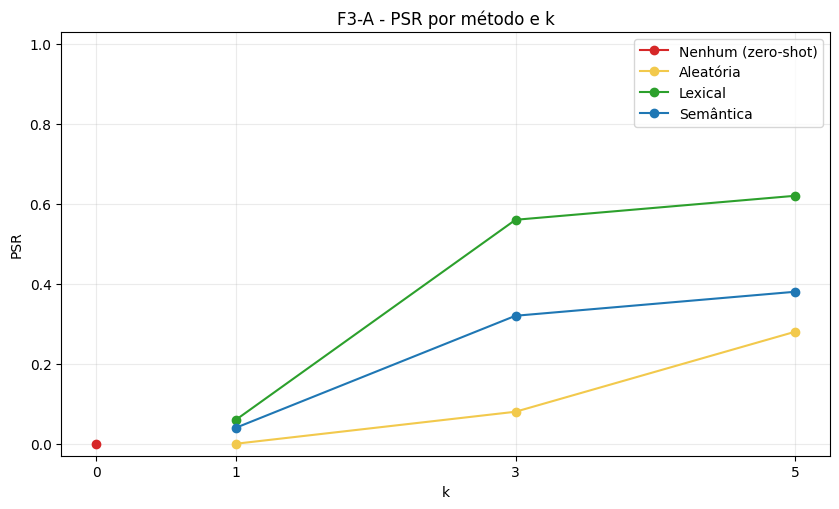

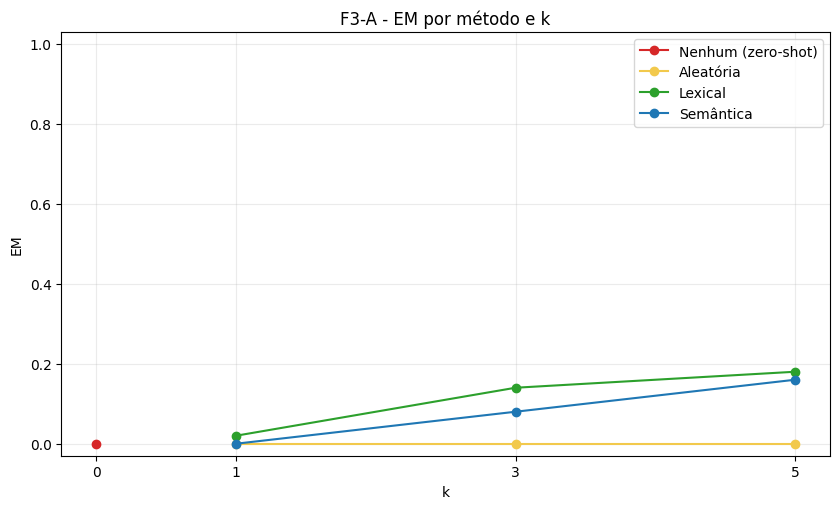

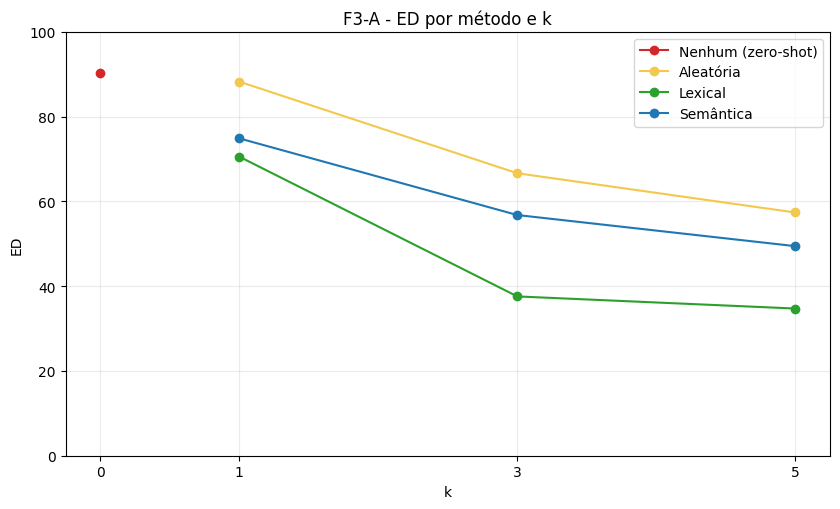

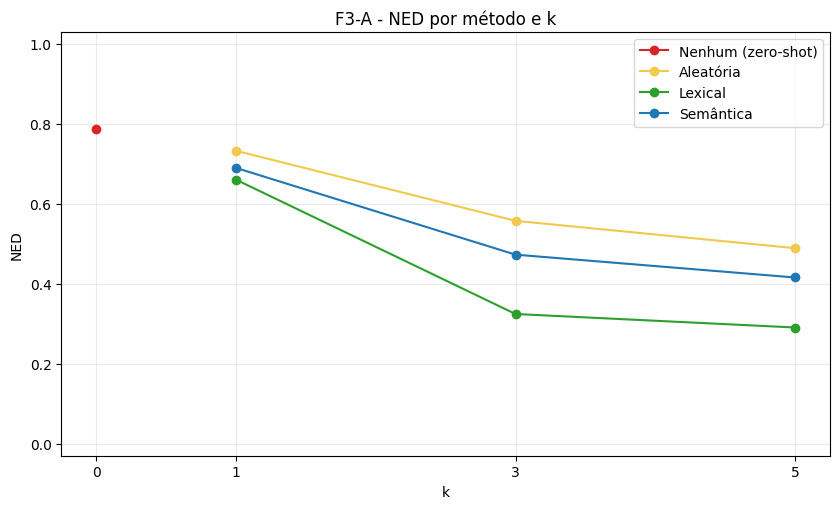

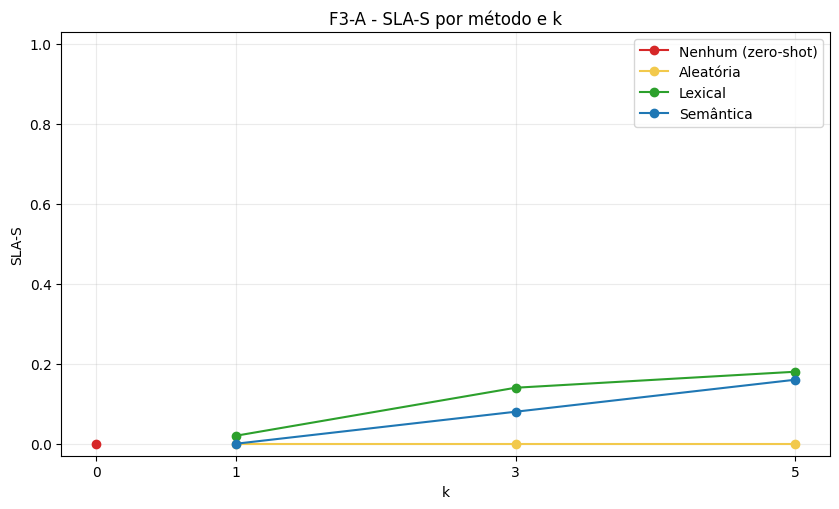

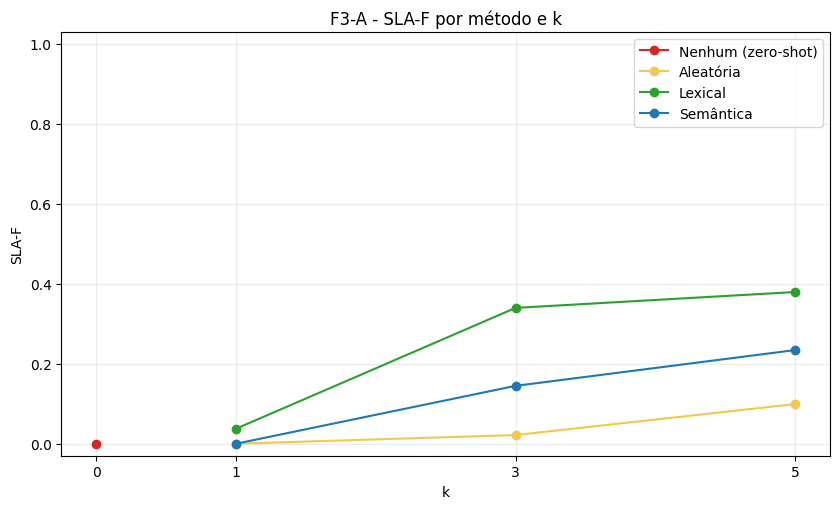

método de seleção,rótulo do método,k,registros,PSR,EM,ED,NED,SLA-S,SLA-F,validade sintática,tokens do prompt,tokens gerados,tempo em segundos
zero_shot,Nenhum (zero-shot),0,50,0.00,0.00,90.18,0.787434,0.00,0.000000,0,488.94,18.34,1.116993
random_seed42,Aleatória,1,50,0.00,0.00,88.24,0.732616,0.00,0.000000,0,542.52,21.62,1.278440
lexical_tfidf,Lexical,1,50,0.06,0.02,70.54,0.660313,0.02,0.037500,3,542.32,17.80,1.067757
semantic_embeddings,Semântica,1,50,0.04,0.00,74.86,0.689701,0.00,0.000000,2,543.70,18.22,1.092051
random_seed42,Aleatória,3,50,0.08,0.00,66.64,0.557389,0.00,0.021667,4,664.62,22.84,1.372892
lexical_tfidf,Lexical,3,50,0.56,0.14,37.58,0.324390,0.14,0.339657,28,665.34,26.00,1.558645
semantic_embeddings,Semântica,3,50,0.32,0.08,56.78,0.472790,0.08,0.144697,16,667.52,23.84,1.434939
random_seed42,Aleatória,5,50,0.28,0.00,57.38,0.488992,0.00,0.099116,14,787.26,23.02,1.418338
lexical_tfidf,Lexical,5,50,0.62,0.18,34.72,0.290621,0.18,0.379338,31,787.74,26.60,1.609341
semantic_embeddings,Semântica,5,50,0.38,0.16,49.44,0.415708,0.16,0.234197,19,794.44,24.22,1.473881


fold,método de seleção,rótulo do método,k,registros,PSR,EM,ED,NED,SLA-S,SLA-F
1,zero_shot,Nenhum (zero-shot),0,10,0.0,0.0,95.1,0.778342,0.0,0.000000
1,random_seed42,Aleatória,1,10,0.0,0.0,80.6,0.690869,0.0,0.000000
1,lexical_tfidf,Lexical,1,10,0.0,0.0,75.1,0.648172,0.0,0.000000
1,semantic_embeddings,Semântica,1,10,0.0,0.0,83.0,0.706747,0.0,0.000000
1,random_seed42,Aleatória,3,10,0.1,0.0,63.9,0.530738,0.0,0.075000
1,lexical_tfidf,Lexical,3,10,0.5,0.1,39.9,0.342381,0.1,0.345707
1,semantic_embeddings,Semântica,3,10,0.3,0.1,50.2,0.442417,0.1,0.181818
1,random_seed42,Aleatória,5,10,0.4,0.0,52.5,0.420693,0.0,0.170833
1,lexical_tfidf,Lexical,5,10,0.5,0.2,40.1,0.335834,0.2,0.365152
1,semantic_embeddings,Semântica,5,10,0.2,0.1,62.8,0.489852,0.1,0.181818


fold,ID,método de seleção,rótulo do método,k,nl,reference nile,response primary raw,nile evaluated,validade sintática,validator feedback
1,campi_001,zero_shot,Nenhum (zero-shot),0,"If a student is in obvious violations of copyright law by using a room's wired connection (ie ResNet) to distribute copyrighted materials, the room's connection will be disabled, and the issue could be sent to Housing Student Judicial Affairs",define intent uniIntent: for group('students') add middlebox('copyright monitoring'),"disable room connection if a student violates copyright law by using room's wired connection (ResNet) to distribute copyrighted materials, report issue to Housing Student Judicial Affairs","disable room connection if a student violates copyright law by using room's wired connection (ResNet) to distribute copyrighted materials, report issue to Housing Student Judicial Affairs",não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'disable') at line 1, column 1.\nContexto: disable room connection if a student violates\n^"
1,campi_002,zero_shot,Nenhum (zero-shot),0,"Currently, the University of Illinois does not have any rate limits",define intent uniIntent: for endpoint('university') unset bandwidth(),"currently, the university of illinois has no rate limits","currently, the university of illinois has no rate limits",não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'currently') at line 1, column 1.\nContexto: currently, the university of illinois has no \n^"
1,campi_011,zero_shot,Nenhum (zero-shot),0,"MSN audio and video communications are not allowed by the University firewall, but the MSN chat, application sharing and file transferring are not blocked","define intent uniIntent: for endpoint('university') add middlebox('firewall') block service('MSN video'), service('MSN audio') allow service('MSN chat'), service('MSN application sharing'), service('file transfer')","MSN audio and video communications are not permitted by the University's firewall, but the MSN chat, application sharing, and file transfer functionalities are not restricted.","MSN audio and video communications are not permitted by the University's firewall, but the MSN chat, application sharing, and file transfer functionalities are not restricted.",não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'MSN') at line 1, column 1.\nContexto: MSN audio and video communications are not pe\n^"
1,campi_012,zero_shot,Nenhum (zero-shot),0,Net2Phone is allowed by the University firewall,define intent uniIntent: for endpoint('university') add middlebox('firewall') allow service('Net2Phone'),`net2phone is permitted by the university firewall`,`net2phone is permitted by the university firewall`,não,"ERRO SINTÁTICO na linha 1, coluna 1: No terminal matches '`' in the current parser context, at line 1 col 1\nContexto: `net2phone is permitted by the university fir\n^"
1,campi_020,zero_shot,Nenhum (zero-shot),0,FTP and SFTP servers are allowed by the University firewall,"define intent uniIntent: for endpoint('university') add middlebox('firewall') allow protocol('ftp'), protocol('sftp')",allowed_by_the_university_firewall,allowed_by_the_university_firewall,não,"ERRO SINTÁTICO na linha 1, coluna 1: Unexpected token Token('NAME', 'allowed_by_the_university_firewall') at line 1, column 1.\nContexto: allowed_by_the_university_firewall\n^"
1,campi_023,zero_shot,Nenhum (zero-shot),0,The system passively monitors the network throughput when traffic is light,define intent uniIntent: for endpoint('network') add middlebox('traffic monitor'),`monitoring_network_throughput_when_traffic_is_light`,`monitoring_network_throughput_when_traffic_is_light`,não,"ERRO SINTÁTICO na linha 1, coluna 1: No terminal matches '`' in the current parser context, at line 1 col 1\nContexto: `monitoring_network_throughput_when_traffic_i\n^"
1,campi_024,zero_shot,Nenhum (zero-shot),0,"There is a 6 GB per 24-hour period upload or download data transf

ID,conditions,PSR,EM,ED,NED,SLA-S,SLA-F,valid outputs
campi_004,10,0.0,0.0,79.3,0.734259,0.0,0.000000,0
campi_005,10,0.0,0.0,78.1,0.605426,0.0,0.000000,0
campi_008,10,0.0,0.0,65.7,0.631731,0.0,0.000000,0
campi_018,10,0.0,0.0,79.6,0.780392,0.0,0.000000,0
campi_023,10,0.0,0.0,50.1,0.604793,0.0,0.000000,0
campi_027,10,0.0,0.0,72.8,0.606233,0.0,0.000000,0
campi_029,10,0.0,0.0,72.5,0.746457,0.0,0.000000,0
campi_038,10,0.0,0.0,49.9,0.479808,0.0,0.000000,0
campi_041,10,0.0,0.0,68.8,0.717990,0.0,0.000000,0
campi_030,10,0.1,0.0,66.3,0.562483,0.0,0.000000,1


Bloco 9 concluído.
Condições consolidadas: 10
Folds consolidados: 5
Saídas inválidas registradas: 383
Gráficos produzidos: 6
Status: OK


In [9]:
# ----------------------------------------------------------
# 9.1 Consolidação por condição e por fold
# ----------------------------------------------------------

summary_df = (
    results_df.groupby(
        ["selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        syntax_valid=("syntax_valid", "sum"),
        prompt_tokens=("prompt_primary_tokens", "mean"),
        generated_tokens=("generated_primary_tokens", "mean"),
        elapsed_seconds=("elapsed_primary_seconds", "mean"),
    )
    .reset_index()
)
summary_df["_ordem_metodo"] = (
    summary_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
summary_df = (
    summary_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
summary_df.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

summary_fold_df = (
    results_df.groupby(
        ["fold", "selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)
summary_fold_df["_ordem_metodo"] = (
    summary_fold_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
summary_fold_df = (
    summary_fold_df
    .sort_values(["fold", "k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
summary_fold_df.to_csv(SUMMARY_FOLD_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.2 Saídas inválidas e análise por exemplo
# ----------------------------------------------------------

invalid_df = results_df.loc[
    ~results_df["syntax_valid"].astype(bool),
    [
        "fold",
        "id",
        "selection_method",
        "selection_label",
        "k",
        "nl",
        "reference_nile",
        "response_primary_raw",
        "nile_evaluated",
        "syntax_valid",
        "validator_feedback",
    ],
].copy()
invalid_df["_ordem_metodo"] = (
    invalid_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
invalid_df = (
    invalid_df
    .sort_values(["fold", "k", "_ordem_metodo", "id"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
invalid_df.to_csv(INVALID_PATH, index=False, encoding="utf-8")

analysis_example_df = (
    results_df.groupby("id", dropna=False)
    .agg(
        conditions=("id", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        valid_outputs=("syntax_valid", "sum"),
    )
    .reset_index()
    .sort_values(["psr", "sla_f", "em", "id"], ascending=[True, True, True, True])
)
analysis_example_df.to_csv(ANALYSIS_EXAMPLE_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.3 Gráficos independentes das seis métricas
# ----------------------------------------------------------

import matplotlib.pyplot as plt

LIMITES_EIXO_Y = {
    "psr": (-0.03, 1.03),
    "em": (-0.03, 1.03),
    "ed": (0.0, 100.0),
    "ned": (-0.03, 1.03),
    "sla_s": (-0.03, 1.03),
    "sla_f": (-0.03, 1.03),
}

TICKS_EIXO_Y = {
    "psr": np.arange(0.0, 1.01, 0.2),
    "em": np.arange(0.0, 1.01, 0.2),
    "ed": np.arange(0.0, 100.1, 20.0),
    "ned": np.arange(0.0, 1.01, 0.2),
    "sla_s": np.arange(0.0, 1.01, 0.2),
    "sla_f": np.arange(0.0, 1.01, 0.2),
}

for metrica, (limite_inferior, limite_superior) in (
    LIMITES_EIXO_Y.items()
):
    valores = pd.to_numeric(
        summary_df[metrica],
        errors="coerce",
    ).dropna()

    if valores.empty:
        raise ValueError(
            f"A métrica {metrica} não possui valores para o gráfico."
        )

    if (
        float(valores.min()) < limite_inferior - 1e-12
        or float(valores.max()) > limite_superior + 1e-12
    ):
        raise ValueError(
            f"A métrica {metrica} ultrapassa a escala gráfica fixada."
        )

GRAFICOS_PATHS = {}

for metric in METRICAS:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    for method in ORDEM_METODOS_EXIBICAO:
        subset = summary_df.loc[summary_df["selection_method"] == method].sort_values("k")
        if subset.empty:
            continue
        ax.plot(
            subset["k"],
            subset[metric],
            marker="o",
            label=ROTULOS_METODOS[method],
            color=CORES_METODOS[method],
        )

    ax.set_title(f"F3-A - {ROTULOS_METRICAS[metric]} por método e k")
    ax.set_xlabel("k")
    ax.set_ylabel(ROTULOS_METRICAS[metric])
    ax.set_xticks([0, 1, 3, 5])
    limite_inferior, limite_superior = LIMITES_EIXO_Y[metric]
    ax.set_ylim(
        limite_inferior,
        limite_superior,
    )
    ax.set_yticks(
        TICKS_EIXO_Y[metric],
    )
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()

    graph_path = GRAFICOS_DIR / f"f3a_{metric}.png"
    fig.savefig(graph_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    GRAFICOS_PATHS[metric] = graph_path


# ----------------------------------------------------------
# 9.4 Exibição dos resultados consolidados
# ----------------------------------------------------------

exibir_tabela(summary_df, "Desempenho consolidado por método e k")
exibir_tabela(summary_fold_df, "Desempenho por fold, método e k", altura_px=460)

if invalid_df.empty:
    print("Nenhuma saída inválida foi registrada.")
else:
    exibir_tabela(invalid_df.head(30), "Amostra das saídas inválidas", altura_px=460)

exibir_tabela(analysis_example_df.head(25), "Exemplos com menor desempenho agregado", altura_px=460)

print("Bloco 9 concluído.")
print(f"Condições consolidadas: {len(summary_df)}")
print(f"Folds consolidados: {summary_fold_df['fold'].nunique()}")
print(f"Saídas inválidas registradas: {len(invalid_df)}")
print(f"Gráficos produzidos: {len(GRAFICOS_PATHS)}")
print("Status: OK")

## Bloco 10 - Manifesto e empacotamento final

### Objetivo

Este bloco encerra a F3-A, executa as barreiras finais de integridade e cria o pacote que será consumido pela F3-B e pela consolidação experimental.

### Barreiras para a execução oficial

O pacote aprovado só é criado quando:

- `MODO_TESTE_RAPIDO=False`;
- existem 500 prompts, 500 gerações e 500 resultados;
- as dez condições contêm 50 exemplos cada;
- todos os resultados atendem ao JSON Schema;
- nenhum registro possui erro de geração;
- nenhum prompt ultrapassa o contexto;
- não existe autocorreção na F3-A;
- os arquivos obrigatórios podem ser reabertos.

A validade sintática das saídas não é exigida para empacotamento, pois PSR é justamente uma variável experimental. Saídas inválidas devem permanecer no conjunto de resultados.

### Manifesto

`manifest.json` registra:

- hashes do F3-modelo e de seus manifestos de origem;
- fonte efetivamente utilizada para o modelo aluno;
- dispositivo, precisão e versões das bibliotecas;
- parâmetros de geração;
- contagens por condição;
- métricas agregadas;
- quantidade de saídas válidas e inválidas;
- tamanho e SHA-256 de cada arquivo.

### Pacote final

O ZIP abre diretamente nos artefatos, sem uma pasta externa repetida. Ele inclui configuração, plano, prompts, respostas brutas, resultados, resumos, auditorias e gráficos.

### Resultado esperado

O arquivo final é:

```text
/kaggle/working/f3a_traducao_direta.zip
```

A F3-A pode ser congelada quando o manifesto e o ZIP passam por todas as verificações.

### Barreira final de tokens

O empacotamento exige igualdade exata entre a contagem realizada na auditoria dos prompts e a contagem registrada durante a inferência. Também é confirmado que `prompt_tokens + max_new_tokens` permanece dentro do limite de contexto.

In [10]:
# ----------------------------------------------------------
# 10.1 Barreiras finais da execução oficial
# ----------------------------------------------------------

if MODO_TESTE_RAPIDO:
    raise RuntimeError(
        "O modo de teste rápido está ativo. Desative-o e execute os Blocos 6 a 10 "
        "para produzir o pacote oficial da F3-A."
    )

if len(prompt_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 500 prompts.")
if len(generation_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 500 gerações.")
if len(result_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 500 resultados.")

tokens_auditados_por_execucao = {
    str(row["execution_id"]): int(row["prompt_tokens"])
    for row in prompt_records
}
tokens_inferencia_por_execucao = {
    str(row["execution_id"]): int(row["prompt_tokens"])
    for row in generation_records
}

if tokens_auditados_por_execucao != tokens_inferencia_por_execucao:
    raise ValueError(
        "A auditoria de tokens diverge dos valores registrados "
        "durante a inferência."
    )

if (
    max(tokens_auditados_por_execucao.values())
    + MAX_NEW_TOKENS_NILE
    > CONTEXT_LIMIT
):
    raise ValueError(
        "Há prompt que ultrapassa o limite de contexto do modelo."
    )

if results_df["execution_id"].duplicated().any() if "execution_id" in results_df.columns else False:
    raise ValueError("Há IDs de execução duplicados nos resultados.")
if not results_df["status"].eq("completed").all():
    raise ValueError("Há resultados com status diferente de completed.")
if results_df["autocorrection_applied"].astype(bool).any():
    raise ValueError("A F3-A não pode conter autocorreção.")
if len(summary_df) != TOTAL_CONDICOES_ESPERADO or not summary_df["records"].eq(50).all():
    raise ValueError("O resumo final não contém dez condições de 50 registros.")
if len(analysis_example_df) != TOTAL_EXEMPLOS_ESPERADO:
    raise ValueError("A análise por exemplo deve conter 50 IDs.")

# A chave execution_id não integra o schema comum; a correspondência é auditada pelo plano.
planned_keys = {
    (row["fold"], row["id"], row["selection_method"], row["k"])
    for row in plan_records
}
result_keys = {
    (int(row["fold"]), row["id"], row["selection_method"], int(row["k"]))
    for row in result_records
}
if planned_keys != result_keys:
    raise ValueError("As chaves dos resultados não correspondem integralmente ao plano.")


# ----------------------------------------------------------
# 10.2 Atualização da configuração consolidada
# ----------------------------------------------------------

config_final = {
    **configuracao_inicial,
    "f3_modelo": {
        "source": str(FONTE_F3_MODELO),
        "source_type": TIPO_FONTE_F3_MODELO,
        "manifest_sha256": f3_modelo_manifest_sha256,
    },
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "source_used": str(MODEL_SOURCE),
        "source_type": MODEL_SOURCE_TYPE,
        "device": model_device,
        "dtype": model_dtype,
        "context_limit": CONTEXT_LIMIT,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "observed": {
        "conditions": int(len(summary_df)),
        "prompts": int(len(prompt_records)),
        "generations": int(len(generation_records)),
        "results": int(len(result_records)),
        "syntax_valid": int(results_df["syntax_valid"].sum()),
        "invalid_outputs": int(len(invalid_df)),
        "prompt_tokens_min": int(token_audit_df["prompt_tokens"].min()),
        "prompt_tokens_max": int(token_audit_df["prompt_tokens"].max()),
        "max_reserved_tokens": int(token_audit_df["reserved_tokens"].max()),
    },
}
write_json(config_final, CONFIG_PATH)


# ----------------------------------------------------------
# 10.3 Inventário e manifesto
# ----------------------------------------------------------

clean_runtime_caches(F3A_DIR)

package_files = [
    CONFIG_PATH,
    PLANO_PATH,
    PROMPTS_PATH,
    TOKEN_AUDIT_PATH,
    GENERATIONS_PATH,
    RESULTS_JSONL_PATH,
    RESULTS_CSV_PATH,
    SUMMARY_PATH,
    SUMMARY_FOLD_PATH,
    INVALID_PATH,
    ANALYSIS_EXAMPLE_PATH,
    EXECUTION_AUDIT_PATH,
    *[GRAFICOS_PATHS[metric] for metric in METRICAS],
]

missing_package_files = [str(path) for path in package_files if not Path(path).is_file()]
if missing_package_files:
    raise FileNotFoundError("Arquivos finais ausentes: " + ", ".join(missing_package_files))

file_inventory = []
for path in package_files:
    path = Path(path)
    if path.is_relative_to(PACOTE_DIR):
        relative = path.relative_to(PACOTE_DIR).as_posix()
    elif path.is_relative_to(GRAFICOS_DIR):
        relative = "graficos/" + path.name
    else:
        relative = path.name
    file_inventory.append({
        "file": relative,
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

manifest = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variant": VARIANTE,
    "description": NOME_ESTRATEGIA,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": DATASET,
    "inputs": {
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
        "f0_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f0_manifest_sha256"),
        "f1_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f1_manifest_sha256"),
        "f2_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f2_manifest_sha256"),
    },
    "experimental_design": {
        "folds": TOTAL_FOLDS_ESPERADO,
        "examples": TOTAL_EXEMPLOS_ESPERADO,
        "conditions": TOTAL_CONDICOES_ESPERADO,
        "records": TOTAL_REGISTROS_ESPERADO,
        "k_values": VALORES_K,
        "few_shot_k_values": K_FEWSHOT,
        "selection_methods": [METODO_ZERO_SHOT, *METODOS_FEWSHOT],
        "formal_equivalent_demonstrations_excluded": True,
    },
    "model": config_final["student_model"],
    "metrics": {
        "names": ["PSR", "EM", "ED", "NED", "SLA-S", "SLA-F"],
        "internal_fields": METRICAS,
        "embedding_metric_used": False,
    },
    "method": {
        "teacher_model_used": False,
        "fine_tuning_used": False,
        "intermediate_representation_used_in_prompt": False,
        "rationales_used_in_prompt": False,
        "autocorrection_used": False,
        "test_reference_exposed": False,
        "checkpoint_resume_enabled": True,
    },
    "results": {
        "syntax_valid": int(results_df["syntax_valid"].sum()),
        "invalid_outputs": int(len(invalid_df)),
        "summary": summary_df.to_dict(orient="records"),
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "packages": {
            "torch": package_version("torch"),
            "transformers": package_version("transformers"),
            "accelerate": package_version("accelerate"),
            "pandas": package_version("pandas"),
            "numpy": package_version("numpy"),
            "lark": package_version("lark"),
            "jsonschema": package_version("jsonschema"),
            "matplotlib": package_version("matplotlib"),
        },
    },
    "files": file_inventory,
}
write_json(manifest, MANIFEST_PATH)


# ----------------------------------------------------------
# 10.4 Criação do ZIP sem pasta externa repetida
# ----------------------------------------------------------

if ZIP_FINAL_PATH.exists():
    ZIP_FINAL_PATH.unlink()

with zipfile.ZipFile(ZIP_FINAL_PATH, "w", compression=zipfile.ZIP_DEFLATED) as package:
    for path, item in zip(package_files, file_inventory):
        package.write(path, arcname=item["file"])
    package.write(MANIFEST_PATH, arcname="manifest.json")

with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    names = package.namelist()
    corrupted = package.testzip()

if corrupted is not None:
    raise ValueError(f"Arquivo corrompido no ZIP: {corrupted}")
if len(names) != len(set(names)):
    raise ValueError("O ZIP contém nomes duplicados.")
if any(name.startswith("f3a_traducao_direta/") for name in names):
    raise ValueError("O ZIP contém uma pasta externa repetida.")

# Conferência dos hashes diretamente no ZIP.
with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    for item in file_inventory:
        data = package.read(item["file"])
        actual = hashlib.sha256(data).hexdigest()
        if actual != item["sha256"]:
            raise ValueError(f"Hash divergente dentro do ZIP: {item['file']}")

final_summary_df = pd.DataFrame([
    {"item": "condições", "value": len(summary_df)},
    {"item": "resultados", "value": len(results_df)},
    {"item": "saídas sintaticamente válidas", "value": int(results_df["syntax_valid"].sum())},
    {"item": "arquivos inventariados", "value": len(file_inventory)},
    {"item": "arquivos no ZIP", "value": len(names)},
    {"item": "ZIP final", "value": str(ZIP_FINAL_PATH)},
])

exibir_tabela(final_summary_df, "Resumo final da F3-A")

print("Bloco 10 concluído.")
print("F3-A concluída e empacotada.")
print(f"Manifesto: {MANIFEST_PATH}")
print(f"ZIP final: {ZIP_FINAL_PATH}")
print("Pasta externa repetida: não")
print("Integridade do ZIP: confirmada")
print("Status: OK")

item,valor
condições,10
resultados,500
saídas sintaticamente válidas,117
arquivos inventariados,18
arquivos no ZIP,19
ZIP final,/kaggle/working/f3a_traducao_direta.zip


Bloco 10 concluído.
F3-A concluída e empacotada.
Manifesto: /kaggle/working/f3a_traducao_direta/pacote/manifest.json
ZIP final: /kaggle/working/f3a_traducao_direta.zip
Pasta externa repetida: não
Integridade do ZIP: confirmada
Status: OK
